# E-ITRAM: Reproducible Explainable IT Risk Assessment and Management

This notebook implements the E-ITRAM analytical and governance workflow defined for the study using the official UNSW-NB15 predefined training and testing partitions.

The workflow includes binary normal-versus-malicious classification, multiclass attack-category classification, validation-based model selection, independent test evaluation, calibration, SHAP and LIME explanations, analytical risk translation, KRIs, risk-appetite comparison, statistical comparison, bootstrap confidence intervals, governance mapping, publication-quality figures, and deployment artifacts.

**Methodological boundary:** UNSW-NB15 is a benchmark cybersecurity dataset. It does not contain institution-specific financial impact data. Therefore, impact is an explicit external input to the risk calculation and is not inferred from the benchmark dataset.

In [ ]:
# Cell 1: Reproducible Google Colab environment
# Run this cell first in a fresh Colab runtime.

%pip install -q --disable-pip-version-check \
    "numpy==2.1.3" \
    "pandas==2.2.3" \
    "scipy==1.14.1" \
    "matplotlib==3.10.0" \
    "seaborn==0.13.2" \
    "scikit-learn==1.6.1" \
    "xgboost==2.1.4" \
    "shap==0.46.0" \
    "lime==0.2.0.1" \
    "statsmodels==0.14.4" \
    "joblib==1.4.2" \
    "openpyxl==3.1.5"

import os
import sys
import json
import time
import math
import random
import warnings
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("=" * 72)
print("E-ITRAM REPRODUCIBLE ENVIRONMENT")
print("=" * 72)
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("=" * 72)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 17.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.1/342.1 MB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.11.1

In [ ]:
# Cell 2: Verify the installed scientific stack

import scipy
import sklearn
import xgboost
import shap
import lime
import statsmodels

versions = {
    "Python": sys.version.split()[0],
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "SciPy": scipy.__version__,
    "Matplotlib": plt.matplotlib.__version__,
    "Seaborn": sns.__version__,
    "Scikit-learn": sklearn.__version__,
    "XGBoost": xgboost.__version__,
    "SHAP": shap.__version__,
    "LIME": getattr(lime, "__version__", "unknown"),
    "Statsmodels": statsmodels.__version__,
    "Joblib": joblib.__version__,
}
display(pd.DataFrame(list(versions.items()), columns=["Package", "Version"]))
print("Environment import verification completed successfully.")

,Package,Version
0,Python,3.13.15
1,NumPy,2.1.3
2,Pandas,2.2.3
3,SciPy,1.14.1
4,Matplotlib,3.10.0
5,Seaborn,0.13.2
6,Scikit-learn,1.6.1
7,XGBoost,2.1.4
8,SHAP,0.46.0
9,LIME,unknown


Environment import verification completed successfully.


In [ ]:
# Cell 3: Project configuration

ROOT = Path("/content/E_ITRAM")
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
FIG_DIR = ROOT / "figures_600dpi"
TABLE_DIR = ROOT / "tables"
REPORT_DIR = ROOT / "reports"

for directory in [DATA_DIR, ARTIFACT_DIR, FIG_DIR, TABLE_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TRAIN_FILE = DATA_DIR / "UNSW_NB15_training-set.csv"
TEST_FILE = DATA_DIR / "UNSW_NB15_testing-set.csv"

EXPECTED_TRAIN_ROWS = 175_341
EXPECTED_TEST_ROWS = 82_332

DPI = 600
FIGSIZE = (7.2, 4.8)

# Analytical demonstration only. Replace with institution-approved impact input for operational use.
DEFAULT_IMPACT_FACTOR = 1.0
RISK_APPETITE_THRESHOLD = 50.0

RISK_BANDS = {
    "Low": (0, 25),
    "Moderate": (25, 50),
    "High": (50, 75),
    "Critical": (75, 101),
}

print("Project root:", ROOT)
print("Training file:", TRAIN_FILE)
print("Testing file :", TEST_FILE)
print("Figure DPI   :", DPI)

Project root: /content/E_ITRAM
Training file: /content/E_ITRAM/data/UNSW_NB15_training-set.csv
Testing file : /content/E_ITRAM/data/UNSW_NB15_testing-set.csv
Figure DPI   : 600


## Dataset acquisition and validation

The study uses the predefined UNSW-NB15 training and testing partitions. The expected sizes are 175,341 training observations and 82,332 testing observations.

The acquisition cell never treats an HTML/error response as a CSV. If the historical download endpoint is unavailable, it asks for the official CSV files to be uploaded. The subsequent validation cell checks the schema and expected partition sizes before modelling.

In [ ]:
# Cell 4: Acquire the official predefined UNSW-NB15 partitions safely

import requests
from IPython.display import display

OFFICIAL_URLS = {
    "train": (
        "https://www.unsw.adfa.edu.au/unsw-canberra-cyber/cybersecurity/"
        "ADFA-NB15-Datasets/a%20part%20of%20training%20and%20testing%20set/"
        "UNSW_NB15_training-set.csv"
    ),
    "test": (
        "https://www.unsw.adfa.edu.au/unsw-canberra-cyber/cybersecurity/"
        "ADFA-NB15-Datasets/a%20part%20of%20training%20and%20testing%20set/"
        "UNSW_NB15_testing-set.csv"
    ),
}

def validate_csv_file(path, expected_rows=None):
    """Validate that path is a readable UNSW-NB15-style CSV."""
    path = Path(path)
    if not path.exists() or path.stat().st_size < 1024:
        return False, "File is missing or too small."

    try:
        sample = pd.read_csv(path, nrows=5, low_memory=False)
    except Exception as exc:
        return False, f"CSV parsing failed: {exc}"

    required = {"label", "attack_cat"}
    missing = required - set(sample.columns)
    if missing:
        return False, f"Missing required columns: {sorted(missing)}"

    if expected_rows is not None:
        try:
            with open(path, "rb") as handle:
                rows = sum(1 for _ in handle) - 1
            if rows != expected_rows:
                return False, f"Expected {expected_rows:,} rows, found {rows:,}."
        except Exception:
            pass

    return True, "Valid schema."

def download_to_path(url, destination):
    """Download to a temporary file and validate before replacing destination."""
    temporary = destination.with_suffix(".download")
    try:
        response = requests.get(
            url,
            stream=True,
            timeout=90,
            headers={"User-Agent": "Mozilla/5.0"},
        )
        response.raise_for_status()

        with open(temporary, "wb") as handle:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    handle.write(chunk)

        ok, message = validate_csv_file(temporary)
        if not ok:
            temporary.unlink(missing_ok=True)
            return False, message

        temporary.replace(destination)
        return True, "Download and validation successful."

    except Exception as exc:
        temporary.unlink(missing_ok=True)
        return False, str(exc)

# Try existing files first.
train_ok, train_msg = validate_csv_file(TRAIN_FILE, EXPECTED_TRAIN_ROWS)
test_ok, test_msg = validate_csv_file(TEST_FILE, EXPECTED_TEST_ROWS)

if not train_ok:
    print("Training file:", train_msg)
    print("Attempting official historical download...")
    train_ok, train_msg = download_to_path(OFFICIAL_URLS["train"], TRAIN_FILE)

if not test_ok:
    print("Testing file:", test_msg)
    print("Attempting official historical download...")
    test_ok, test_msg = download_to_path(OFFICIAL_URLS["test"], TEST_FILE)

# If the historical endpoint is unavailable, request upload.
if not train_ok or not test_ok:
    print("\nThe automatic download did not produce both valid predefined CSV files.")
    print("Please upload BOTH official files when the Colab upload dialog appears:")
    print("  1. UNSW_NB15_training-set.csv")
    print("  2. UNSW_NB15_testing-set.csv")

    from google.colab import files
    uploaded = files.upload()

    for uploaded_name, uploaded_bytes in uploaded.items():
        destination = DATA_DIR / Path(uploaded_name).name
        destination.write_bytes(uploaded_bytes)

    train_ok, train_msg = validate_csv_file(TRAIN_FILE, EXPECTED_TRAIN_ROWS)
    test_ok, test_msg = validate_csv_file(TEST_FILE, EXPECTED_TEST_ROWS)

if not train_ok:
    raise RuntimeError(
        f"Training dataset is invalid: {train_msg}\n"
        f"Required file: {TRAIN_FILE}"
    )

if not test_ok:
    raise RuntimeError(
        f"Testing dataset is invalid: {test_msg}\n"
        f"Required file: {TEST_FILE}"
    )

print("\n✓ Training partition validated.")
print("✓ Testing partition validated.")

Testing file: File is missing or too small.
Attempting official historical download...

The automatic download did not produce both valid predefined CSV files.
Please upload BOTH official files when the Colab upload dialog appears:
  1. UNSW_NB15_training-set.csv
  2. UNSW_NB15_testing-set.csv


Saving UNSW_NB15_training-set.csv to UNSW_NB15_training-set (1).csv
Saving UNSW_NB15_testing-set.csv to UNSW_NB15_testing-set.csv

✓ Training partition validated.
✓ Testing partition validated.


In [ ]:
# Cell 5: Load and validate the predefined partitions

train_df = pd.read_csv(TRAIN_FILE, low_memory=False)
test_df = pd.read_csv(TEST_FILE, low_memory=False)

required_columns = {"label", "attack_cat"}

missing_train = required_columns - set(train_df.columns)
missing_test = required_columns - set(test_df.columns)

if missing_train:
    raise ValueError(f"Training set missing columns: {sorted(missing_train)}")
if missing_test:
    raise ValueError(f"Testing set missing columns: {sorted(missing_test)}")

if len(train_df) != EXPECTED_TRAIN_ROWS:
    raise ValueError(
        f"Training partition has {len(train_df):,} rows. "
        f"The predefined UNSW-NB15 training partition should contain "
        f"{EXPECTED_TRAIN_ROWS:,} rows."
    )

if len(test_df) != EXPECTED_TEST_ROWS:
    raise ValueError(
        f"Testing partition has {len(test_df):,} rows. "
        f"The predefined UNSW-NB15 testing partition should contain "
        f"{EXPECTED_TEST_ROWS:,} rows."
    )

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)
print("Required columns verified:", sorted(required_columns))

display(train_df.head())

Training shape: (175341, 45)
Testing shape : (82332, 45)
Required columns verified: ['attack_cat', 'label']


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
# Cell 6: Data quality assessment and target normalization

def quality_report(df, name):
    rows = []
    for column in df.columns:
        series = df[column]
        if pd.api.types.is_numeric_dtype(series):
            infinite = int(np.isinf(series.to_numpy(dtype=float, na_value=np.nan)).sum())
        else:
            infinite = 0

        rows.append({
            "column": column,
            "dtype": str(series.dtype),
            "missing": int(series.isna().sum()),
            "infinite": infinite,
            "unique": int(series.nunique(dropna=False)),
        })

    report = pd.DataFrame(rows).set_index("column")
    print(f"{name}: {len(df):,} rows × {len(df.columns)} columns")
    display(report)
    return report

train_quality = quality_report(train_df, "Training partition")
test_quality = quality_report(test_df, "Testing partition")

# Normalize labels without learning anything from the test partition.
for frame in [train_df, test_df]:
    frame["label"] = pd.to_numeric(frame["label"], errors="coerce")
    if frame["label"].isna().any():
        raise ValueError("The label column contains non-numeric or missing values.")

    frame["label"] = frame["label"].astype(int)

    frame["attack_cat"] = (
        frame["attack_cat"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    # The benchmark encodes normal traffic with label 0.
    frame.loc[frame["label"] == 0, "attack_cat"] = "normal"

canonical_attack_names = {
    "normal": "Normal",
    "fuzzers": "Fuzzers",
    "analysis": "Analysis",
    "backdoors": "Backdoors",
    "backdoor": "Backdoors",
    "dos": "DoS",
    "exploits": "Exploits",
    "generic": "Generic",
    "reconnaissance": "Reconnaissance",
    "reconnaissance ": "Reconnaissance",
    "shellcode": "Shellcode",
    "worms": "Worms",
}

for frame in [train_df, test_df]:
    frame["attack_cat"] = frame["attack_cat"].map(
        lambda value: canonical_attack_names.get(str(value), str(value).strip().title())
    )

if train_df["attack_cat"].isna().any() or test_df["attack_cat"].isna().any():
    raise ValueError("attack_cat contains missing values after normalization.")

print("Target normalization completed.")
print("Training labels:")
display(train_df["attack_cat"].value_counts().rename_axis("class").reset_index(name="count"))

Training partition: 175,341 rows × 45 columns


,dtype,missing,infinite,unique
column,,,,
id,int64,0,0,175341
dur,float64,0,0,74039
proto,object,0,0,133
service,object,0,0,13
state,object,0,0,9
spkts,int64,0,0,480
dpkts,int64,0,0,443
sbytes,int64,0,0,7214
dbytes,int64,0,0,6660


Testing partition: 82,332 rows × 45 columns


,dtype,missing,infinite,unique
column,,,,
id,int64,0,0,82332
dur,float64,0,0,39888
proto,object,0,0,131
service,object,0,0,13
state,object,0,0,7
spkts,int64,0,0,420
dpkts,int64,0,0,436
sbytes,int64,0,0,4489
dbytes,int64,0,0,4034


Target normalization completed.
Training labels:


,class,count
0,Normal,56000
1,Generic,40000
2,Exploits,33393
3,Fuzzers,18184
4,DoS,12264
5,Reconnaissance,10491
6,Analysis,2000
7,Backdoors,1746
8,Shellcode,1133
9,Worms,130


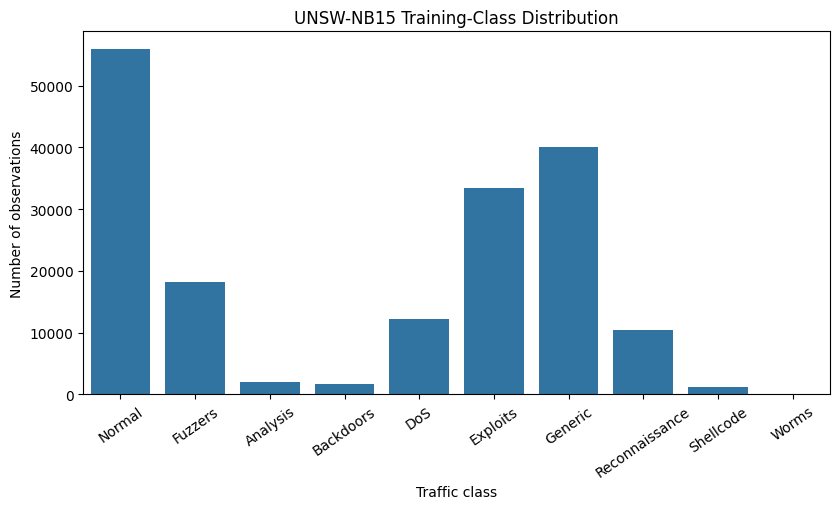

In [ ]:
# Cell 7: Training-class distribution and publication figure

CLASS_ORDER = [
    "Normal", "Fuzzers", "Analysis", "Backdoors", "DoS",
    "Exploits", "Generic", "Reconnaissance", "Shellcode", "Worms"
]

train_counts = (
    train_df["attack_cat"]
    .value_counts()
    .reindex(CLASS_ORDER, fill_value=0)
    .rename_axis("class")
    .reset_index(name="count")
)

def save_publication_figure(fig, stem):
    png_path = FIG_DIR / f"{stem}.png"
    pdf_path = FIG_DIR / f"{stem}.pdf"
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    return png_path, pdf_path

fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.barplot(data=train_counts, x="class", y="count", ax=ax)
ax.set_xlabel("Traffic class")
ax.set_ylabel("Number of observations")
ax.set_title("UNSW-NB15 Training-Class Distribution")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
save_publication_figure(fig, "Figure_1_training_class_distribution")
plt.show()
plt.close(fig)

train_counts.to_csv(TABLE_DIR / "Table_1_training_class_distribution.csv", index=False)

In [ ]:
# Cell 8: Define leakage-controlled predictors and targets

DROP_COLUMNS = [
    column for column in ["id", "label", "attack_cat"]
    if column in train_df.columns
]

X_all = train_df.drop(columns=DROP_COLUMNS).copy()
X_test = test_df.drop(columns=DROP_COLUMNS).copy()

y_binary = train_df["label"].astype(int).copy()
y_binary_test = test_df["label"].astype(int).copy()

y_multi = train_df["attack_cat"].astype(str).copy()
y_multi_test = test_df["attack_cat"].astype(str).copy()

FEATURE_COLUMNS = X_all.columns.tolist()

categorical_features = X_all.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_features = [
    column for column in FEATURE_COLUMNS
    if column not in categorical_features
]

if not FEATURE_COLUMNS:
    raise ValueError("No predictor columns remain after leakage control.")

if set(FEATURE_COLUMNS) & {"label", "attack_cat"}:
    raise AssertionError("Target columns leaked into the predictor set.")

print("Total predictors:", len(FEATURE_COLUMNS))
print("Numeric predictors:", len(numeric_features))
print("Categorical predictors:", len(categorical_features))
print("Excluded columns:", DROP_COLUMNS)
print("✓ Target leakage check passed.")

Total predictors: 42
Numeric predictors: 39
Categorical predictors: 3
Excluded columns: ['id', 'label', 'attack_cat']
✓ Target leakage check passed.


In [ ]:
# Cell 9: Training-only validation split

from sklearn.model_selection import train_test_split

X_fit_bin, X_val_bin, y_fit_bin, y_val_bin = train_test_split(
    X_all,
    y_binary,
    test_size=0.20,
    stratify=y_binary,
    random_state=SEED,
)

X_fit_multi, X_val_multi, y_fit_multi, y_val_multi = train_test_split(
    X_all,
    y_multi,
    test_size=0.20,
    stratify=y_multi,
    random_state=SEED,
)

print("Binary fit:", X_fit_bin.shape)
print("Binary validation:", X_val_bin.shape)
print("Binary test:", X_test.shape)
print("Multiclass fit:", X_fit_multi.shape)
print("Multiclass validation:", X_val_multi.shape)
print("Multiclass test:", X_test.shape)

Binary fit: (140272, 42)
Binary validation: (35069, 42)
Binary test: (82332, 42)
Multiclass fit: (140272, 42)
Multiclass validation: (35069, 42)
Multiclass test: (82332, 42)


In [ ]:
# Cell 10: Leakage-safe preprocessing pipelines

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_lr, numeric_features),
        ("cat", categorical_lr, categorical_features),
    ],
)

numeric_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_tree, numeric_features),
        ("cat", categorical_tree, categorical_features),
    ],
)

# Fit only on the binary fit partition.
lr_Xfit = preprocessor_lr.fit_transform(X_fit_bin)
lr_Xval = preprocessor_lr.transform(X_val_bin)

tree_Xfit = preprocessor_tree.fit_transform(X_fit_bin)
tree_Xval = preprocessor_tree.transform(X_val_bin)

feature_names_lr = preprocessor_lr.get_feature_names_out()
feature_names_tree = preprocessor_tree.get_feature_names_out()

print("LR transformed fit matrix:", lr_Xfit.shape)
print("Tree transformed fit matrix:", tree_Xfit.shape)
print("✓ Preprocessing parameters were learned from training-fit data only.")

LR transformed fit matrix: (140272, 192)
Tree transformed fit matrix: (140272, 192)
✓ Preprocessing parameters were learned from training-fit data only.


In [ ]:
# Cell 11: Model candidates and validation-based selection

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
)

def evaluate_binary_validation(name, model, X_val, y_val):
    prediction = model.predict(X_val)
    probability = model.predict_proba(X_val)[:, 1]

    return {
        "model": name,
        "accuracy": float((prediction == y_val).mean()),
        "macro_f1": float(f1_score(y_val, prediction, average="macro")),
        "balanced_accuracy": float(
            balanced_accuracy_score(y_val, prediction)
        ),
        "roc_auc": float(roc_auc_score(y_val, probability)),
        "pr_auc": float(average_precision_score(y_val, probability)),
    }

candidate_records = []

# Logistic Regression
for C in [0.1, 1.0, 10.0]:
    model = LogisticRegression(
        C=C,
        max_iter=1000,
        solver="liblinear",
        random_state=SEED,
    )
    start = time.perf_counter()
    model.fit(lr_Xfit, y_fit_bin)
    elapsed = time.perf_counter() - start

    record = evaluate_binary_validation(
        "Logistic Regression", model, lr_Xval, y_val_bin
    )
    record.update({"C": C, "fit_time_s": elapsed})
    candidate_records.append(("Logistic Regression", record, model))

# Random Forest
for n_estimators, max_depth in [
    (250, None),
    (250, 20),
    (400, 20),
]:
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=SEED,
        class_weight="balanced_subsample",
    )
    start = time.perf_counter()
    model.fit(tree_Xfit, y_fit_bin)
    elapsed = time.perf_counter() - start

    record = evaluate_binary_validation(
        "Random Forest", model, tree_Xval, y_val_bin
    )
    record.update({
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "fit_time_s": elapsed,
    })
    candidate_records.append(("Random Forest", record, model))

# XGBoost
for max_depth, learning_rate, n_estimators in [
    (5, 0.05, 250),
    (7, 0.05, 300),
    (7, 0.10, 250),
]:
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=0.90,
        colsample_bytree=0.90,
        min_child_weight=1,
        reg_lambda=1.0,
        reg_alpha=0.0,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=SEED,
    )
    start = time.perf_counter()
    model.fit(tree_Xfit, y_fit_bin)
    elapsed = time.perf_counter() - start

    record = evaluate_binary_validation(
        "XGBoost", model, tree_Xval, y_val_bin
    )
    record.update({
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "n_estimators": n_estimators,
        "fit_time_s": elapsed,
    })
    candidate_records.append(("XGBoost", record, model))

candidate_table = pd.DataFrame([record for _, record, _ in candidate_records])

# Validation-only selection score.
candidate_table["selection_score"] = (
    0.40 * candidate_table["macro_f1"]
    + 0.30 * candidate_table["balanced_accuracy"]
    + 0.20 * candidate_table["roc_auc"]
    + 0.10 * candidate_table["pr_auc"]
)

# Select the best configuration per model family.
best_records = {}
for family in ["Logistic Regression", "Random Forest", "XGBoost"]:
    subset = candidate_table[candidate_table["model"] == family].copy()
    best_records[family] = subset.sort_values(
        ["selection_score", "macro_f1", "balanced_accuracy"],
        ascending=False,
    ).iloc[0].to_dict()

validation_summary = pd.DataFrame(best_records).T.reset_index(drop=True)
display(validation_summary)

validation_summary.to_csv(
    TABLE_DIR / "Table_2_validation_model_selection.csv",
    index=False,
)

,model,accuracy,macro_f1,balanced_accuracy,roc_auc,pr_auc,C,fit_time_s,n_estimators,max_depth,learning_rate,selection_score
0,Logistic Regression,0.937637,0.925221,0.909072,0.984563,0.991648,10.0,28.399136,NaN,NaN,NaN,0.938887
1,Random Forest,0.959679,0.953239,0.949528,0.993786,0.996941,NaN,78.808655,250.0,NaN,NaN,0.964605
2,XGBoost,0.960478,0.954214,0.950968,0.99409,0.997199,NaN,17.631265,250.0,7.0,0.1,0.965514


In [ ]:
# Cell 12: Refit final binary models on the complete predefined training partition

from sklearn.base import clone

preprocessor_lr_full = clone(preprocessor_lr).fit(X_all, y_binary)
preprocessor_tree_full = clone(preprocessor_tree).fit(X_all, y_binary)

X_train_lr_full = preprocessor_lr_full.transform(X_all)
X_test_lr_full = preprocessor_lr_full.transform(X_test)

X_train_tree_full = preprocessor_tree_full.transform(X_all)
X_test_tree_full = preprocessor_tree_full.transform(X_test)

final_models = {}
train_times = {}
test_predictions = {}
test_probabilities = {}

# Logistic Regression
lr_best = best_records["Logistic Regression"]
lr_final = LogisticRegression(
    C=float(lr_best["C"]),
    max_iter=1000,
    solver="liblinear",
    random_state=SEED,
)

start = time.perf_counter()
lr_final.fit(X_train_lr_full, y_binary)
train_times["Logistic Regression"] = time.perf_counter() - start

final_models["Logistic Regression"] = (
    lr_final,
    preprocessor_lr_full,
    X_train_lr_full,
    X_test_lr_full,
)

# Random Forest
rf_best = best_records["Random Forest"]
rf_final = RandomForestClassifier(
    n_estimators=int(rf_best["n_estimators"]),
    max_depth=None if pd.isna(rf_best["max_depth"]) else int(rf_best["max_depth"]),
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=SEED,
    class_weight="balanced_subsample",
)

start = time.perf_counter()
rf_final.fit(X_train_tree_full, y_binary)
train_times["Random Forest"] = time.perf_counter() - start

final_models["Random Forest"] = (
    rf_final,
    preprocessor_tree_full,
    X_train_tree_full,
    X_test_tree_full,
)

# XGBoost
xgb_best = best_records["XGBoost"]
xgb_final = XGBClassifier(
    n_estimators=int(xgb_best["n_estimators"]),
    max_depth=int(xgb_best["max_depth"]),
    learning_rate=float(xgb_best["learning_rate"]),
    subsample=0.90,
    colsample_bytree=0.90,
    min_child_weight=1,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=SEED,
)

start = time.perf_counter()
xgb_final.fit(X_train_tree_full, y_binary)
train_times["XGBoost"] = time.perf_counter() - start

final_models["XGBoost"] = (
    xgb_final,
    preprocessor_tree_full,
    X_train_tree_full,
    X_test_tree_full,
)

for name, (model, _, _, Xte) in final_models.items():
    start = time.perf_counter()
    test_predictions[name] = model.predict(Xte)
    test_probabilities[name] = model.predict_proba(Xte)[:, 1]
    print(
        f"{name}: training={train_times[name]:.2f}s, "
        f"test_prediction={time.perf_counter() - start:.2f}s"
    )

Logistic Regression: training=22.31s, test_prediction=0.02s
Random Forest: training=99.12s, test_prediction=4.96s
XGBoost: training=24.11s, test_prediction=1.13s


In [ ]:
# Cell 13: Independent binary test evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)

def binary_metrics(y_true, y_pred, probability):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, probability),
        "PR-AUC": average_precision_score(y_true, probability),
        "FPR": fp / (fp + tn) if (fp + tn) else np.nan,
        "FNR": fn / (fn + tp) if (fn + tp) else np.nan,
        "Brier": brier_score_loss(y_true, probability),
    }

binary_results = pd.DataFrame({
    name: binary_metrics(
        y_binary_test,
        test_predictions[name],
        test_probabilities[name],
    )
    for name in final_models
}).T

display(binary_results.style.format("{:.6f}"))

binary_results.to_csv(
    TABLE_DIR / "Table_3_binary_classification_performance.csv"
)

,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,ROC-AUC,PR-AUC,FPR,FNR,Brier
Logistic Regression,0.811786,0.755209,0.973815,0.850693,0.793543,0.956283,0.966506,0.386730,0.026185,0.112626
Random Forest,0.870500,0.815906,0.987647,0.893599,0.857310,0.980165,0.983624,0.273027,0.012353,0.082531
XGBoost,0.873196,0.821526,0.983323,0.895172,0.860797,0.983598,0.987992,0.261730,0.016677,0.082795


In [ ]:
# Cell 14: Select the principal E-ITRAM binary model using validation evidence only

selection_table = validation_summary.copy()

selection_table = selection_table.sort_values(
    ["selection_score", "macro_f1", "balanced_accuracy"],
    ascending=False,
).reset_index(drop=True)

SELECTED_MODEL_NAME = str(selection_table.loc[0, "model"])

selected_model, selected_prep, selected_X_train, selected_X_test = (
    final_models[SELECTED_MODEL_NAME]
)

selected_prob = test_probabilities[SELECTED_MODEL_NAME]
selected_pred = test_predictions[SELECTED_MODEL_NAME]

print("Principal E-ITRAM model:", SELECTED_MODEL_NAME)
display(selection_table)

selection_table.to_csv(
    TABLE_DIR / "Table_4_principal_model_selection.csv",
    index=False,
)

Principal E-ITRAM model: XGBoost


,model,accuracy,macro_f1,balanced_accuracy,roc_auc,pr_auc,C,fit_time_s,n_estimators,max_depth,learning_rate,selection_score
0,XGBoost,0.960478,0.954214,0.950968,0.99409,0.997199,NaN,17.631265,250.0,7.0,0.1,0.965514
1,Random Forest,0.959679,0.953239,0.949528,0.993786,0.996941,NaN,78.808655,250.0,NaN,NaN,0.964605
2,Logistic Regression,0.937637,0.925221,0.909072,0.984563,0.991648,10.0,28.399136,NaN,NaN,NaN,0.938887


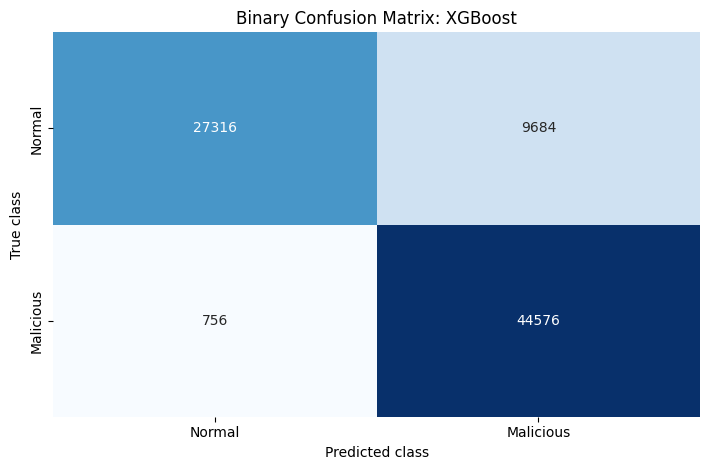

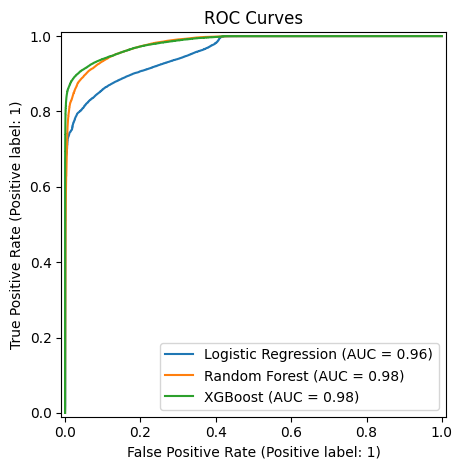

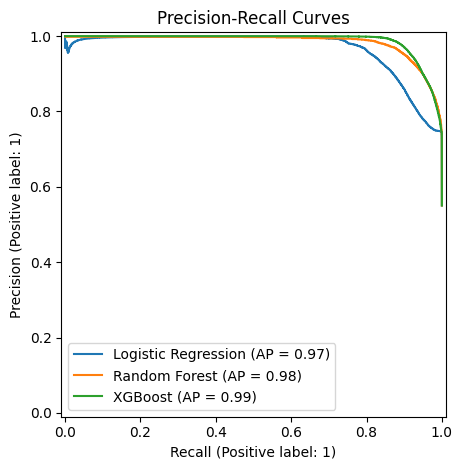

In [ ]:
# Cell 15: Binary confusion matrix, ROC curves, and PR curves

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=FIGSIZE)
cm = confusion_matrix(y_binary_test, selected_pred, labels=[0, 1])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal", "Malicious"],
    yticklabels=["Normal", "Malicious"],
    ax=ax,
)

ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title(f"Binary Confusion Matrix: {SELECTED_MODEL_NAME}")
fig.tight_layout()
save_publication_figure(fig, "Figure_3_confusion_matrix")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=FIGSIZE)
for name in final_models:
    RocCurveDisplay.from_predictions(
        y_binary_test,
        test_probabilities[name],
        name=name,
        ax=ax,
    )
ax.set_title("ROC Curves")
fig.tight_layout()
save_publication_figure(fig, "Figure_4_ROC_curves")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=FIGSIZE)
for name in final_models:
    PrecisionRecallDisplay.from_predictions(
        y_binary_test,
        test_probabilities[name],
        name=name,
        ax=ax,
    )
ax.set_title("Precision-Recall Curves")
fig.tight_layout()
save_publication_figure(fig, "Figure_5_PR_curves")
plt.show()
plt.close(fig)

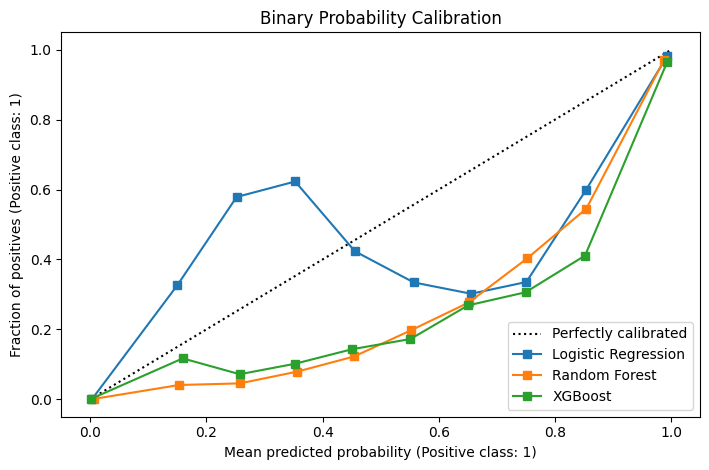

,Model,Brier,LogLoss
0,Logistic Regression,0.112626,0.313539
1,Random Forest,0.082531,0.258628
2,XGBoost,0.082795,0.241060


In [ ]:
# Cell 16: Calibration diagnostics

from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import log_loss

calibration_rows = []

fig, ax = plt.subplots(figsize=FIGSIZE)

for name in final_models:
    probability = test_probabilities[name]

    CalibrationDisplay.from_predictions(
        y_binary_test,
        probability,
        n_bins=10,
        name=name,
        ax=ax,
    )

    calibration_rows.append({
        "Model": name,
        "Brier": brier_score_loss(y_binary_test, probability),
        "LogLoss": log_loss(
            y_binary_test,
            np.column_stack([1.0 - probability, probability]),
        ),
    })

ax.set_title("Binary Probability Calibration")
fig.tight_layout()
save_publication_figure(fig, "Figure_6_calibration")
plt.show()
plt.close(fig)

calibration_df = pd.DataFrame(calibration_rows)
display(calibration_df)
calibration_df.to_csv(
    TABLE_DIR / "Table_5_calibration_diagnostics.csv",
    index=False,
)

In [ ]:
# Cell 17: Multiclass attack-category model development

from sklearn.preprocessing import LabelEncoder

multi_encoder = LabelEncoder()
multi_encoder.fit(y_multi)

y_fit_multi_enc = multi_encoder.transform(y_fit_multi)
y_val_multi_enc = multi_encoder.transform(y_val_multi)
y_multi_test_enc = multi_encoder.transform(y_multi_test)

multi_prep = clone(preprocessor_tree).fit(X_fit_multi, y_fit_multi)

Xm_fit = multi_prep.transform(X_fit_multi)
Xm_val = multi_prep.transform(X_val_multi)

multi_candidates = []

for max_depth, learning_rate, n_estimators in [
    (5, 0.05, 250),
    (7, 0.05, 300),
    (7, 0.10, 250),
]:
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=0.90,
        colsample_bytree=0.90,
        min_child_weight=1,
        reg_lambda=1.0,
        objective="multi:softprob",
        num_class=len(multi_encoder.classes_),
        eval_metric="mlogloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=SEED,
    )

    start = time.perf_counter()
    model.fit(Xm_fit, y_fit_multi_enc)
    elapsed = time.perf_counter() - start

    prediction = model.predict(Xm_val)

    multi_candidates.append({
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "n_estimators": n_estimators,
        "macro_f1": f1_score(
            y_val_multi_enc,
            prediction,
            average="macro",
        ),
        "fit_time_s": elapsed,
        "model": model,
    })

multi_validation = pd.DataFrame([
    {key: value for key, value in row.items() if key != "model"}
    for row in multi_candidates
])

best_multi_index = multi_validation["macro_f1"].idxmax()
best_multi = multi_candidates[int(best_multi_index)]

multi_prep_full = clone(preprocessor_tree).fit(X_all, y_multi)
Xm_full = multi_prep_full.transform(X_all)
Xm_test_full = multi_prep_full.transform(X_test)

multi_final = XGBClassifier(
    n_estimators=int(best_multi["n_estimators"]),
    max_depth=int(best_multi["max_depth"]),
    learning_rate=float(best_multi["learning_rate"]),
    subsample=0.90,
    colsample_bytree=0.90,
    min_child_weight=1,
    reg_lambda=1.0,
    objective="multi:softprob",
    num_class=len(multi_encoder.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=SEED,
)

start = time.perf_counter()
multi_final.fit(
    Xm_full,
    multi_encoder.transform(y_multi),
)
multi_train_time = time.perf_counter() - start

multi_pred_enc = multi_final.predict(Xm_test_full)
multi_prob = multi_final.predict_proba(Xm_test_full)
multi_pred = multi_encoder.inverse_transform(multi_pred_enc)

print("Multiclass classes:", list(multi_encoder.classes_))
print("Multiclass training time:", round(multi_train_time, 2), "s")
display(multi_validation)

Multiclass classes: ['Analysis', 'Backdoors', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']
Multiclass training time: 225.31 s


,max_depth,learning_rate,n_estimators,macro_f1,fit_time_s
0,5,0.05,250,0.590423,159.292012
1,7,0.05,300,0.606591,223.065185
2,7,0.10,250,0.614203,185.118163


,precision,recall,f1-score,support
Analysis,0.045671,0.098966,0.062500,677.000000
Backdoors,0.030511,0.068611,0.042239,583.000000
DoS,0.581330,0.100514,0.171393,4089.000000
Exploits,0.604349,0.861301,0.710301,11132.000000
Fuzzers,0.301851,0.578357,0.396674,6062.000000
Generic,0.997768,0.971385,0.984400,18871.000000
Normal,0.960317,0.756081,0.846048,37000.000000
Reconnaissance,0.933443,0.810355,0.867555,3496.000000
Shellcode,0.369538,0.783069,0.502120,378.000000
Worms,0.642857,0.409091,0.500000,44.000000


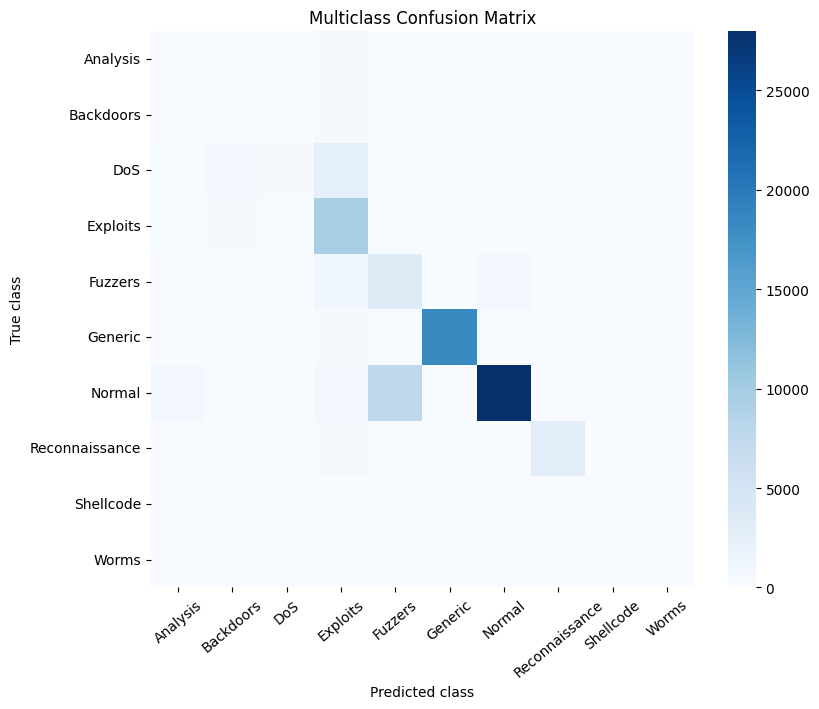

In [ ]:
# Cell 18: Multiclass classification results and confusion matrix

from sklearn.metrics import classification_report

multi_report = classification_report(
    y_multi_test,
    multi_pred,
    labels=multi_encoder.classes_,
    output_dict=True,
    zero_division=0,
)

multi_report_df = pd.DataFrame(multi_report).T
display(multi_report_df)

multi_report_df.to_csv(
    TABLE_DIR / "Table_6_multiclass_classification_performance.csv"
)

fig, ax = plt.subplots(figsize=(8.5, 7.2))
cm_multi = confusion_matrix(
    y_multi_test,
    multi_pred,
    labels=multi_encoder.classes_,
)

sns.heatmap(
    cm_multi,
    cmap="Blues",
    cbar=True,
    xticklabels=multi_encoder.classes_,
    yticklabels=multi_encoder.classes_,
    ax=ax,
)

ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Multiclass Confusion Matrix")
ax.tick_params(axis="x", rotation=40)
fig.tight_layout()
save_publication_figure(fig, "Figure_7_multiclass_confusion_matrix")
plt.show()
plt.close(fig)

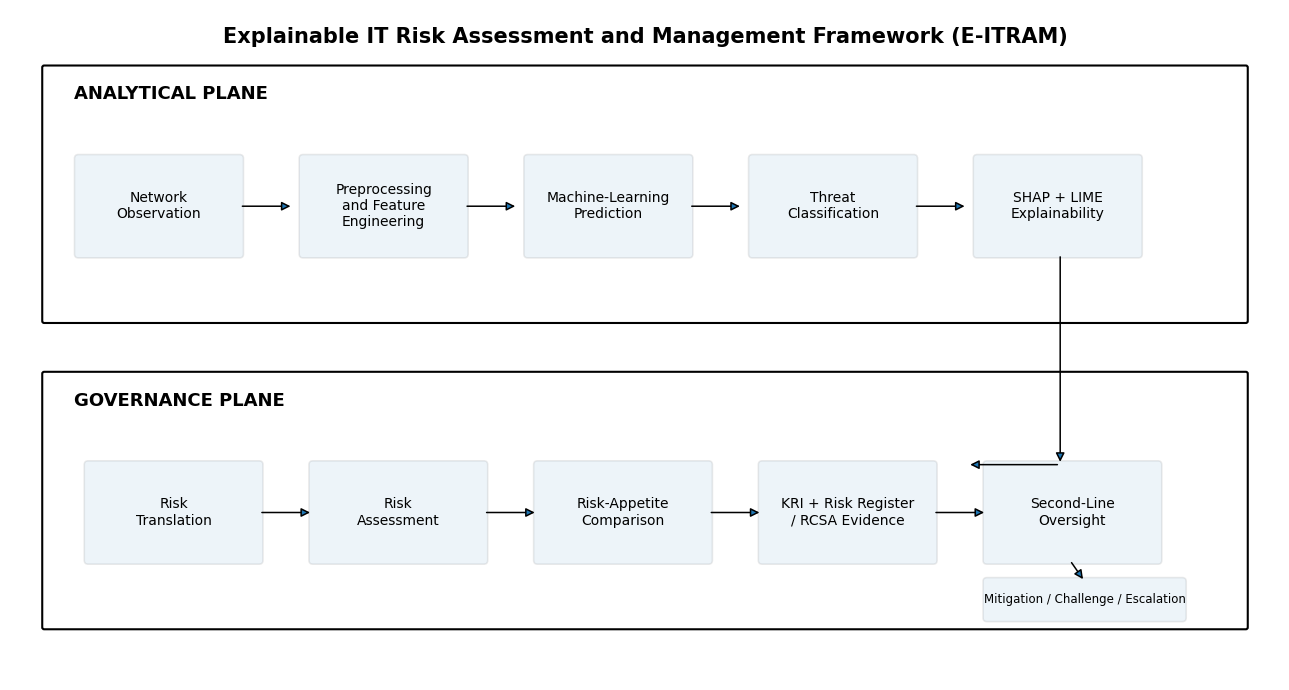

In [ ]:
# Cell 19: E-ITRAM architecture figure

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 13)
ax.set_ylim(0, 7)
ax.axis("off")

ax.add_patch(
    FancyBboxPatch(
        (0.35, 3.75), 12.3, 2.65,
        boxstyle="round,pad=0.02",
        fill=False,
        linewidth=1.5,
    )
)

ax.add_patch(
    FancyBboxPatch(
        (0.35, 0.55), 12.3, 2.65,
        boxstyle="round,pad=0.02",
        fill=False,
        linewidth=1.5,
    )
)

ax.text(0.65, 6.12, "ANALYTICAL PLANE",
        fontsize=13, fontweight="bold", va="center")
ax.text(0.65, 2.92, "GOVERNANCE PLANE",
        fontsize=13, fontweight="bold", va="center")

def architecture_box(x, y, w, h, text, fontsize=10):
    ax.add_patch(
        FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.04",
            fill=True,
            alpha=0.08,
            linewidth=1.2,
        )
    )
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        wrap=True,
    )

def architecture_arrow(x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=13,
            linewidth=1.1,
        )
    )

analytical_x = [0.7, 3.0, 5.3, 7.6, 9.9]
analytical_labels = [
    "Network\nObservation",
    "Preprocessing\nand Feature\nEngineering",
    "Machine-Learning\nPrediction",
    "Threat\nClassification",
    "SHAP + LIME\nExplainability",
]

for x, label in zip(analytical_x, analytical_labels):
    architecture_box(x, 4.45, 1.65, 1.0, label)

for x in [2.35, 4.65, 6.95, 9.25]:
    architecture_arrow(x, 4.95, x + 0.55, 4.95)

governance_x = [0.8, 3.1, 5.4, 7.7, 10.0]
governance_labels = [
    "Risk\nTranslation",
    "Risk\nAssessment",
    "Risk-Appetite\nComparison",
    "KRI + Risk Register\n/ RCSA Evidence",
    "Second-Line\nOversight",
]

for x, label in zip(governance_x, governance_labels):
    architecture_box(x, 1.25, 1.75, 1.0, label)

for x in [2.55, 4.85, 7.15, 9.45]:
    architecture_arrow(x, 1.75, x + 0.55, 1.75)

architecture_arrow(10.75, 4.45, 10.75, 2.25)
architecture_arrow(10.75, 2.25, 9.8, 2.25)

architecture_box(
    10.0, 0.65, 2.0, 0.38,
    "Mitigation / Challenge / Escalation",
    fontsize=8.5,
)
architecture_arrow(10.85, 1.25, 11.0, 1.03)

ax.text(
    6.5, 6.72,
    "Explainable IT Risk Assessment and Management Framework (E-ITRAM)",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout()
save_publication_figure(fig, "Figure_2_EITRAM_architecture")
plt.show()
plt.close(fig)

,Feature,Mean absolute SHAP value
6,num__sttl,3.006640
31,num__ct_dst_sport_ltm,0.838307
28,num__ct_state_ttl,0.702625
3,num__sbytes,0.604878
23,num__smean,0.528314
174,cat__service_dns,0.467295
37,num__ct_srv_dst,0.388851
27,num__ct_srv_src,0.253512
32,num__ct_dst_src_ltm,0.209909
4,num__dbytes,0.164171


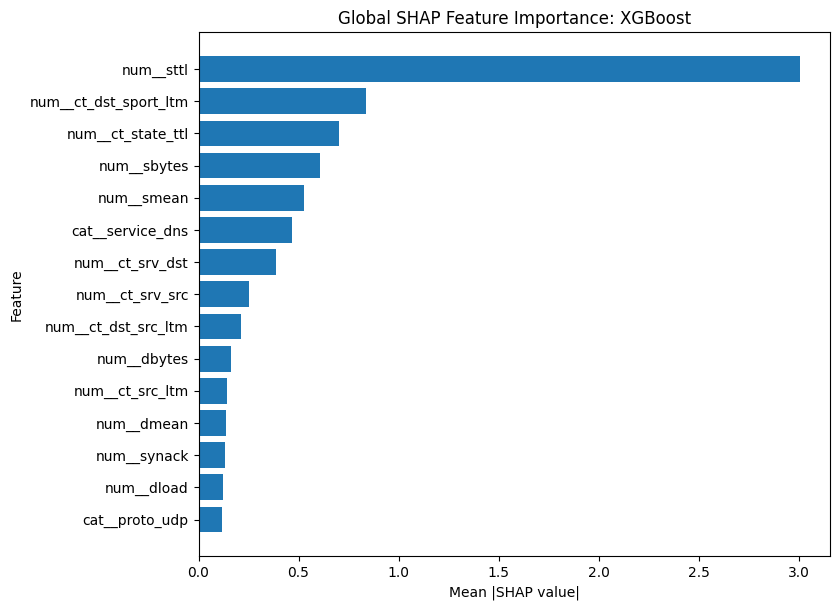

In [ ]:
# Cell 20: Global SHAP explanation

import shap

# Use bounded samples for computational reproducibility.
# Use the selected binary model's own transformed feature space.
selected_X_train_matrix = selected_X_train
selected_X_test_matrix = selected_X_test
SHAP_BACKGROUND_N = min(1000, selected_X_train_matrix.shape[0])
SHAP_EVAL_N = min(5000, selected_X_test_matrix.shape[0])

rng = np.random.default_rng(SEED)
background_indices = rng.choice(
    selected_X_train_matrix.shape[0],
    SHAP_BACKGROUND_N,
    replace=False,
)
evaluation_indices = rng.choice(
    selected_X_test_matrix.shape[0],
    SHAP_EVAL_N,
    replace=False,
)

X_shap_background = selected_X_train_matrix[background_indices]
X_shap_eval = selected_X_test_matrix[evaluation_indices]

def extract_binary_shap_matrix(shap_values):
    """Normalize SHAP output across supported SHAP output formats."""
    if isinstance(shap_values, list):
        return np.asarray(shap_values[-1])

    values = np.asarray(shap_values)

    if values.ndim == 3:
        # Typical binary shape: observations × features × classes.
        return values[:, :, -1]

    return values

if SELECTED_MODEL_NAME == "Logistic Regression":
    # LinearExplainer is the appropriate SHAP explainer for the linear model.
    shap_explainer = shap.LinearExplainer(
        selected_model,
        X_shap_background,
    )
else:
    shap_explainer = shap.TreeExplainer(selected_model)

raw_shap_values = shap_explainer.shap_values(X_shap_eval)
shap_matrix = extract_binary_shap_matrix(raw_shap_values)

if shap_matrix.shape[1] != len(
    preprocessor_lr_full.get_feature_names_out()
    if SELECTED_MODEL_NAME == "Logistic Regression"
    else preprocessor_tree_full.get_feature_names_out()
):
    raise ValueError("SHAP feature count does not match transformed feature count.")

if SELECTED_MODEL_NAME == "Logistic Regression":
    shap_feature_names = preprocessor_lr_full.get_feature_names_out()
else:
    shap_feature_names = preprocessor_tree_full.get_feature_names_out()

shap_global = pd.DataFrame({
    "Feature": shap_feature_names,
    "Mean absolute SHAP value": np.abs(shap_matrix).mean(axis=0),
}).sort_values(
    "Mean absolute SHAP value",
    ascending=False,
)

display(shap_global.head(20))

shap_global.to_csv(
    TABLE_DIR / "Table_7_SHAP_global_risk_drivers.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(8.5, 6.2))
top = shap_global.head(15).sort_values("Mean absolute SHAP value")
ax.barh(
    top["Feature"],
    top["Mean absolute SHAP value"],
)
ax.set_xlabel("Mean |SHAP value|")
ax.set_ylabel("Feature")
ax.set_title(f"Global SHAP Feature Importance: {SELECTED_MODEL_NAME}")
fig.tight_layout()
save_publication_figure(fig, "Figure_8_global_SHAP")
plt.show()
plt.close(fig)

In [ ]:
# Cell 21: Risk translation, representative events, and analytical risk bands

impact_vector = np.full(
    len(selected_prob),
    DEFAULT_IMPACT_FACTOR,
    dtype=float,
)

risk_score = np.clip(
    100.0 * selected_prob * impact_vector,
    0.0,
    100.0,
)

def risk_category(score):
    if score < 25:
        return "Low"
    if score < 50:
        return "Moderate"
    if score < 75:
        return "High"
    return "Critical"

risk_category_vector = np.array([
    risk_category(score)
    for score in risk_score
])

risk_df = test_df.copy()
risk_df["predicted_malicious_probability"] = selected_prob
risk_df["predicted_binary_class"] = selected_pred
risk_df["impact_factor"] = impact_vector
risk_df["risk_score"] = risk_score
risk_df["risk_category"] = risk_category_vector
risk_df["predicted_attack_category"] = multi_pred

risk_order = np.argsort(risk_score)

low_idx = int(risk_order[len(risk_order) // 10])
mid_idx = int(risk_order[len(risk_order) // 2])
high_idx = int(risk_order[-max(1, len(risk_order) // 10)])

representative_indices = {
    "Low": low_idx,
    "Moderate": mid_idx,
    "High/Critical": high_idx,
}

representative_table = risk_df.iloc[
    list(representative_indices.values())
][[
    "label",
    "attack_cat",
    "predicted_malicious_probability",
    "impact_factor",
    "risk_score",
    "risk_category",
]]

display(representative_table)
representative_table.to_csv(
    TABLE_DIR / "Table_8_representative_risk_events.csv"
)

,label,attack_cat,predicted_malicious_probability,impact_factor,risk_score,risk_category
27343,0,Normal,0.000026,1.0,0.002630,Low
65495,1,Generic,0.935953,1.0,93.595261,Critical
18594,1,Generic,0.999980,1.0,99.998047,Critical


,Feature,SHAP,AbsSHAP
31,num__ct_dst_sport_ltm,2.910345,2.910345
174,cat__service_dns,1.910421,1.910421
6,num__sttl,1.768921,1.768921
36,num__ct_src_ltm,1.134494,1.134494
3,num__sbytes,1.129472,1.129472
27,num__ct_srv_src,-1.011468,1.011468
23,num__smean,0.879521,0.879521
28,num__ct_state_ttl,0.348753,0.348753
37,num__ct_srv_dst,-0.338670,0.338670
172,cat__service_-,0.239733,0.239733


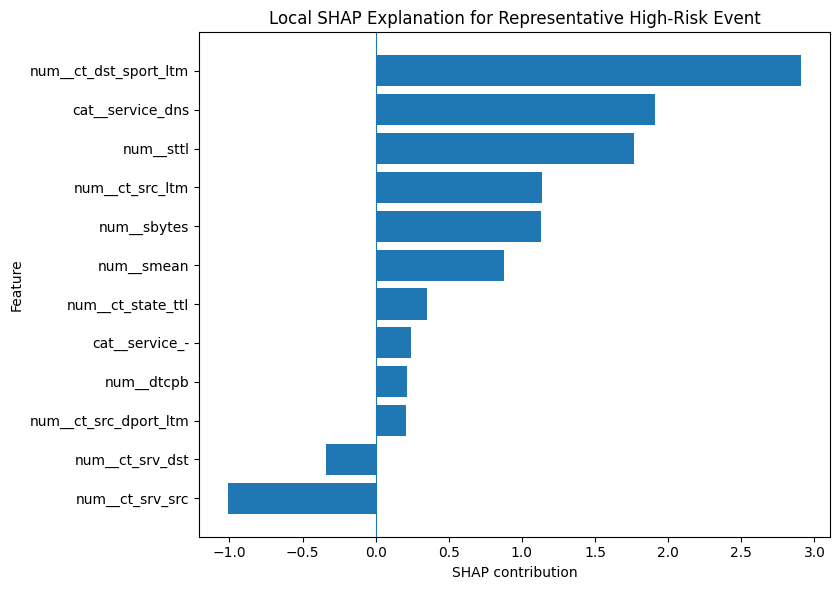

,Feature condition,LIME weight
0,62.00 < num__sttl <= 254.00,0.701955
1,1.00 < num__ct_state_ttl <= 2.00,0.244698
2,cat__proto_wsn <= 0.00,0.236659
3,cat__proto_trunk-2 <= 0.00,-0.211082
4,cat__proto_idrp <= 0.00,0.205932
5,cat__proto_vrrp <= 0.00,0.191600
6,cat__proto_kryptolan <= 0.00,0.188407
7,cat__proto_eigrp <= 0.00,0.177484
8,cat__proto_dcn <= 0.00,0.176752
9,cat__proto_iso-tp4 <= 0.00,0.161962


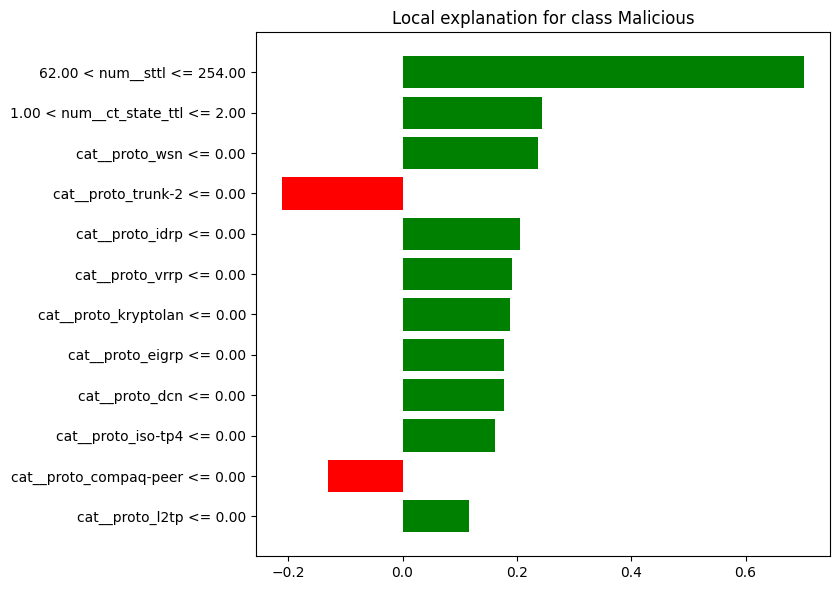

Local SHAP and LIME explanations generated successfully.


In [ ]:
# Cell 22: Local SHAP and LIME explanation for the representative high-risk event

from lime.lime_tabular import LimeTabularExplainer

local_test_position = high_idx

if SELECTED_MODEL_NAME == "Logistic Regression":
    X_local = X_test_lr_full[[local_test_position]]
    local_shap_explainer = shap.LinearExplainer(
        selected_model,
        X_shap_background,
    )
    local_raw = local_shap_explainer.shap_values(X_local)
    local_values = extract_binary_shap_matrix(local_raw)[0]
    local_feature_names = preprocessor_lr_full.get_feature_names_out()
    local_model_matrix = X_train_lr_full
else:
    X_local = X_test_tree_full[[local_test_position]]
    local_shap_explainer = shap.TreeExplainer(selected_model)
    local_raw = local_shap_explainer.shap_values(X_local)
    local_values = extract_binary_shap_matrix(local_raw)[0]
    local_feature_names = preprocessor_tree_full.get_feature_names_out()
    local_model_matrix = X_train_tree_full

local_shap_df = pd.DataFrame({
    "Feature": local_feature_names,
    "SHAP": local_values,
    "AbsSHAP": np.abs(local_values),
}).sort_values(
    "AbsSHAP",
    ascending=False,
)

display(local_shap_df.head(15))

local_shap_df.to_csv(
    TABLE_DIR / "Table_9_local_SHAP_explanation.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(8.5, 6.0))
local_top = local_shap_df.head(12).sort_values("SHAP")
ax.barh(local_top["Feature"], local_top["SHAP"])
ax.axvline(0, linewidth=0.8)
ax.set_xlabel("SHAP contribution")
ax.set_ylabel("Feature")
ax.set_title("Local SHAP Explanation for Representative High-Risk Event")
fig.tight_layout()
save_publication_figure(fig, "Figure_9_local_SHAP")
plt.show()
plt.close(fig)

# LIME is fitted on a deterministic bounded sample to keep the notebook tractable.
LIME_BACKGROUND_N = min(10000, local_model_matrix.shape[0])
lime_rng = np.random.default_rng(SEED)
lime_indices = lime_rng.choice(
    local_model_matrix.shape[0],
    LIME_BACKGROUND_N,
    replace=False,
)

lime_explainer = LimeTabularExplainer(
    np.asarray(local_model_matrix[lime_indices]),
    feature_names=list(local_feature_names),
    class_names=["Normal", "Malicious"],
    mode="classification",
    discretize_continuous=True,
    random_state=SEED,
)

lime_exp = lime_explainer.explain_instance(
    np.asarray(X_local[0]),
    selected_model.predict_proba,
    num_features=12,
)

lime_df = pd.DataFrame(
    lime_exp.as_list(),
    columns=["Feature condition", "LIME weight"],
)

display(lime_df)

lime_df.to_csv(
    TABLE_DIR / "Table_10_local_LIME_explanation.csv",
    index=False,
)

lime_fig = lime_exp.as_pyplot_figure()
lime_fig.set_size_inches(8.5, 6.0)
lime_fig.tight_layout()
save_publication_figure(lime_fig, "Figure_10_local_LIME")
plt.show()
plt.close(lime_fig)

print("Local SHAP and LIME explanations generated successfully.")

## Publication-grade empirical evaluation

The following cells strengthen the implementation for submission: generalization-gap analysis, multiclass imbalance/error analysis, multi-observation SHAP/LIME agreement and stability, SHAP deletion faithfulness, a genuine component-contribution ablation, impact sensitivity, comprehensive uncertainty analysis, computational reproducibility, and automated audit checks.

The ablation deliberately does **not** claim that SHAP or LIME improve predictive accuracy. Those components are evaluated by explanation and governance utility metrics, while the ML prediction component is evaluated by predictive metrics.

In [ ]:
# Cell 24: Publication controls and robust helper functions

import re
from scipy.stats import spearmanr
from sklearn.metrics import matthews_corrcoef

BOOTSTRAP_N = 2000
XAI_EVAL_N = min(300, len(X_test))
LIME_EVENTS = min(30, XAI_EVAL_N)
LIME_REPEATS = 3
LIME_NUM_SAMPLES = 2000
XAI_TOP_K = [1, 3, 5, 10]
IMPACT_SCENARIOS = [0.25, 0.50, 0.75, 1.00]

def canonical_feature_name(name):
    """Map transformed/one-hot names back to the original predictor."""
    text = re.sub(r"^(num|cat)__", "", str(name))
    for original in FEATURE_COLUMNS:
        if text == original or text.startswith(original + "_"):
            return original
    return text.split("=")[0].strip()

def stratified_indices(y, n, seed=SEED):
    y = pd.Series(y).reset_index(drop=True)
    if n >= len(y):
        return np.arange(len(y))
    from sklearn.model_selection import train_test_split
    idx = np.arange(len(y))
    selected, _ = train_test_split(
        idx, train_size=n, stratify=y, random_state=seed
    )
    return np.sort(selected)

def bootstrap_ci(y_true, y_pred, probability, metric, n_boot=BOOTSTRAP_N, seed=SEED):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    probability = np.asarray(probability)
    rng = np.random.default_rng(seed)
    values = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        yt, yp, pp = y_true[idx], y_pred[idx], probability[idx]
        if metric in {"roc_auc", "pr_auc"} and np.unique(yt).size < 2:
            continue
        if metric == "accuracy":
            value = accuracy_score(yt, yp)
        elif metric == "precision":
            value = precision_score(yt, yp, zero_division=0)
        elif metric == "recall":
            value = recall_score(yt, yp, zero_division=0)
        elif metric == "f1":
            value = f1_score(yt, yp, zero_division=0)
        elif metric == "balanced_accuracy":
            value = balanced_accuracy_score(yt, yp)
        elif metric == "roc_auc":
            value = roc_auc_score(yt, pp)
        elif metric == "pr_auc":
            value = average_precision_score(yt, pp)
        elif metric == "brier":
            value = brier_score_loss(yt, pp)
        else:
            raise ValueError(metric)
        if np.isfinite(value):
            values.append(float(value))
    if len(values) < 100:
        return np.nan, np.nan
    return tuple(np.quantile(values, [0.025, 0.975]))

print("Publication controls initialized.")
print("XAI observations:", XAI_EVAL_N, "| LIME events:", LIME_EVENTS)
print("Bootstrap replicates:", BOOTSTRAP_N)

In [ ]:
# Cell 25: Validation-to-test generalization gap

val_record = best_records[SELECTED_MODEL_NAME]
test_macro_f1 = f1_score(y_binary_test, selected_pred, average="macro")

generalization_df = pd.DataFrame([
    ["Accuracy", float(val_record["accuracy"]), float(binary_results.loc[SELECTED_MODEL_NAME, "Accuracy"])],
    ["Macro-F1", float(val_record["macro_f1"]), float(test_macro_f1)],
    ["Balanced Accuracy", float(val_record["balanced_accuracy"]), float(binary_results.loc[SELECTED_MODEL_NAME, "Balanced Accuracy"])],
    ["ROC-AUC", float(val_record["roc_auc"]), float(binary_results.loc[SELECTED_MODEL_NAME, "ROC-AUC"])],
    ["PR-AUC", float(val_record["pr_auc"]), float(binary_results.loc[SELECTED_MODEL_NAME, "PR-AUC"])],
], columns=["Metric", "Validation", "Independent test"])

generalization_df["Absolute gap"] = (
    generalization_df["Validation"] - generalization_df["Independent test"]
)
generalization_df["Relative gap (%)"] = (
    100 * generalization_df["Absolute gap"] /
    generalization_df["Validation"].replace(0, np.nan)
)

display(generalization_df)
generalization_df.to_csv(
    TABLE_DIR / "Table_20_validation_test_generalization_gap.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=FIGSIZE)
plot_df = generalization_df.melt(
    id_vars="Metric",
    value_vars=["Validation", "Independent test"],
    var_name="Partition",
    value_name="Score",
)
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Partition", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title(f"Validation-to-Test Generalization: {SELECTED_MODEL_NAME}")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
save_publication_figure(fig, "Figure_13_validation_test_generalization")
plt.show()
plt.close(fig)

print("Largest absolute gap:", round(generalization_df["Absolute gap"].abs().max(), 4))

In [ ]:
# Cell 26: Publication-grade multiclass summary and minority-class analysis

multi_accuracy = accuracy_score(y_multi_test, multi_pred)
multi_balanced_accuracy = balanced_accuracy_score(y_multi_test, multi_pred)
multi_macro_precision = precision_score(y_multi_test, multi_pred, average="macro", zero_division=0)
multi_macro_recall = recall_score(y_multi_test, multi_pred, average="macro", zero_division=0)
multi_macro_f1 = f1_score(y_multi_test, multi_pred, average="macro", zero_division=0)
multi_weighted_f1 = f1_score(y_multi_test, multi_pred, average="weighted", zero_division=0)
multi_mcc = matthews_corrcoef(multi_encoder.transform(y_multi_test), multi_pred_enc)

multiclass_summary_df = pd.DataFrame([{
    "Accuracy": multi_accuracy,
    "Balanced Accuracy": multi_balanced_accuracy,
    "Macro Precision": multi_macro_precision,
    "Macro Recall": multi_macro_recall,
    "Macro F1": multi_macro_f1,
    "Weighted F1": multi_weighted_f1,
    "MCC": multi_mcc,
}])
display(multiclass_summary_df)
multiclass_summary_df.to_csv(
    TABLE_DIR / "Table_21_multiclass_summary_metrics.csv", index=False
)

class_error_df = multi_report_df.drop(
    index=["accuracy", "macro avg", "weighted avg"], errors="ignore"
).copy()
class_error_df["support"] = pd.to_numeric(class_error_df["support"])
class_error_df["support_group"] = np.where(
    class_error_df["support"] < class_error_df["support"].median(),
    "Below-median support",
    "At/above-median support",
)
display(class_error_df.sort_values("f1-score"))
class_error_df.to_csv(
    TABLE_DIR / "Table_22_multiclass_classwise_error_analysis.csv"
)

cm_norm = confusion_matrix(
    y_multi_test, multi_pred,
    labels=multi_encoder.classes_,
    normalize="true",
)
fig, ax = plt.subplots(figsize=(9.0, 7.6))
sns.heatmap(
    cm_norm, cmap="Blues", vmin=0, vmax=1, cbar=True,
    xticklabels=multi_encoder.classes_,
    yticklabels=multi_encoder.classes_, ax=ax,
)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Normalized Multiclass Confusion Matrix (Row-wise Recall)")
ax.tick_params(axis="x", rotation=40)
fig.tight_layout()
save_publication_figure(fig, "Figure_14_multiclass_confusion_matrix_normalized")
plt.show()
plt.close(fig)

In [ ]:
# Cell 27: Global SHAP aggregation by original predictor

shap_feature_groups = pd.DataFrame({
    "Encoded feature": list(shap_feature_names),
    "Original feature": [canonical_feature_name(x) for x in shap_feature_names],
    "Mean absolute SHAP": np.abs(shap_matrix).mean(axis=0),
})
shap_grouped = (
    shap_feature_groups.groupby("Original feature", as_index=False)
    ["Mean absolute SHAP"].sum()
    .sort_values("Mean absolute SHAP", ascending=False)
)
display(shap_grouped.head(20))
shap_grouped.to_csv(
    TABLE_DIR / "Table_23_SHAP_original_feature_groups.csv", index=False
)

fig, ax = plt.subplots(figsize=(8.5, 6.2))
top = shap_grouped.head(15).sort_values("Mean absolute SHAP")
ax.barh(top["Original feature"], top["Mean absolute SHAP"])
ax.set_xlabel("Aggregated mean |SHAP value|")
ax.set_ylabel("Original predictor")
ax.set_title(f"Global SHAP Importance by Original Predictor: {SELECTED_MODEL_NAME}")
fig.tight_layout()
save_publication_figure(fig, "Figure_15_global_SHAP_original_features")
plt.show()
plt.close(fig)

In [ ]:
# Cell 28: Representative local SHAP and LIME with original-feature mapping

from lime.lime_tabular import LimeTabularExplainer

local_test_position = int(high_idx)
if SELECTED_MODEL_NAME == "Logistic Regression":
    X_local = X_test_lr_full[[local_test_position]]
    local_explainer = shap.LinearExplainer(selected_model, X_shap_background)
    local_values = extract_binary_shap_matrix(
        local_explainer.shap_values(X_local)
    )[0]
    local_feature_names = preprocessor_lr_full.get_feature_names_out()
    local_model_matrix = X_train_lr_full
else:
    X_local = X_test_tree_full[[local_test_position]]
    local_explainer = shap.TreeExplainer(selected_model)
    local_values = extract_binary_shap_matrix(
        local_explainer.shap_values(X_local)
    )[0]
    local_feature_names = preprocessor_tree_full.get_feature_names_out()
    local_model_matrix = X_train_tree_full

local_shap_df = pd.DataFrame({
    "Encoded feature": local_feature_names,
    "Original feature": [canonical_feature_name(x) for x in local_feature_names],
    "SHAP": local_values,
})
local_grouped = (
    local_shap_df.groupby("Original feature", as_index=False)["SHAP"].sum()
)
local_grouped["AbsSHAP"] = local_grouped["SHAP"].abs()
local_grouped = local_grouped.sort_values("AbsSHAP", ascending=False)

display(local_grouped.head(15))
local_grouped.to_csv(
    TABLE_DIR / "Table_24_local_SHAP_original_features.csv", index=False
)

fig, ax = plt.subplots(figsize=(8.5, 6.0))
local_top = local_grouped.head(12).sort_values("SHAP")
ax.barh(local_top["Original feature"], local_top["SHAP"])
ax.axvline(0, linewidth=0.8)
ax.set_xlabel("Aggregated local SHAP contribution")
ax.set_ylabel("Original predictor")
ax.set_title("Local SHAP Explanation for Representative High-Risk Event")
fig.tight_layout()
save_publication_figure(fig, "Figure_16_local_SHAP_original_features")
plt.show()
plt.close(fig)

LIME_BACKGROUND_N = min(10000, local_model_matrix.shape[0])
lime_rng = np.random.default_rng(SEED)
lime_indices = lime_rng.choice(
    local_model_matrix.shape[0], LIME_BACKGROUND_N, replace=False
)
lime_explainer = LimeTabularExplainer(
    np.asarray(local_model_matrix[lime_indices]),
    feature_names=list(local_feature_names),
    class_names=["Normal", "Malicious"],
    mode="classification",
    discretize_continuous=True,
    random_state=SEED,
)
lime_exp = lime_explainer.explain_instance(
    np.asarray(X_local[0]),
    selected_model.predict_proba,
    num_features=12,
    num_samples=LIME_NUM_SAMPLES,
)
lime_df = pd.DataFrame(
    lime_exp.as_list(),
    columns=["Feature condition", "LIME weight"],
)
lime_df["Original feature"] = [
    canonical_feature_name(str(x).split()[0])
    for x in lime_df["Feature condition"]
]
display(lime_df)
lime_df.to_csv(
    TABLE_DIR / "Table_25_local_LIME_explanation.csv", index=False
)

lime_fig = lime_exp.as_pyplot_figure()
lime_fig.set_size_inches(8.5, 6.0)
lime_fig.tight_layout()
save_publication_figure(lime_fig, "Figure_17_local_LIME")
plt.show()
plt.close(lime_fig)

In [ ]:
# Cell 29: Multi-event SHAP/LIME agreement and repeated-LIME stability

def shap_top_original_features(position, k=5):
    row = selected_X_test[position:position + 1]
    explainer = (
        shap.LinearExplainer(selected_model, X_shap_background)
        if SELECTED_MODEL_NAME == "Logistic Regression"
        else shap.TreeExplainer(selected_model)
    )
    values = extract_binary_shap_matrix(explainer.shap_values(row))[0]
    frame = pd.DataFrame({
        "feature": [canonical_feature_name(x) for x in local_feature_names],
        "abs": np.abs(values),
    })
    return (
        frame.groupby("feature", as_index=False)["abs"].sum()
        .sort_values("abs", ascending=False)
        .head(k)["feature"].tolist()
    )

def lime_top_original_features(position, k=5, seed=SEED):
    row = (
        X_test_lr_full[position]
        if SELECTED_MODEL_NAME == "Logistic Regression"
        else X_test_tree_full[position]
    )
    if hasattr(row, "toarray"):
        row = row.toarray().ravel()
    else:
        row = np.asarray(row).ravel()
    explainer = LimeTabularExplainer(
        np.asarray(local_model_matrix[lime_indices]),
        feature_names=list(local_feature_names),
        class_names=["Normal", "Malicious"],
        mode="classification",
        discretize_continuous=True,
        random_state=int(seed),
    )
    exp = explainer.explain_instance(
        np.asarray(row),
        selected_model.predict_proba,
        num_features=max(10, k),
        num_samples=LIME_NUM_SAMPLES,
    )
    return list(dict.fromkeys(
        canonical_feature_name(str(condition).split()[0])
        for condition, _ in exp.as_list()
    ))[:k]

def jaccard(a, b):
    a, b = set(a), set(b)
    union = a | b
    return len(a & b) / len(union) if union else np.nan

xai_indices = stratified_indices(
    y_binary_test, XAI_EVAL_N, seed=SEED + 10
)

agreement_rows = []
stability_rows = []

for pos in xai_indices[:LIME_EVENTS]:
    shap_top = shap_top_original_features(int(pos), 5)
    lime_runs = [
        lime_top_original_features(
            int(pos), 5, seed=SEED + 1000 + r
        )
        for r in range(LIME_REPEATS)
    ]
    agreement_rows.append({
        "test_position": int(pos),
        "true_class": int(y_binary_test.iloc[pos]),
        "SHAP_LIME_Top5_overlap": len(set(shap_top) & set(lime_runs[0])),
        "SHAP_LIME_Top5_Jaccard": jaccard(shap_top, lime_runs[0]),
    })
    pairwise = [
        jaccard(lime_runs[i], lime_runs[j])
        for i in range(len(lime_runs))
        for j in range(i + 1, len(lime_runs))
    ]
    stability_rows.append({
        "test_position": int(pos),
        "LIME_repeated_Top5_Jaccard": float(np.nanmean(pairwise)),
    })

xai_agreement_df = pd.DataFrame(agreement_rows)
xai_stability_df = pd.DataFrame(stability_rows)
xai_agreement_summary = pd.DataFrame([{
    "Events evaluated": len(xai_agreement_df),
    "Mean SHAP-LIME Top5 Jaccard": xai_agreement_df["SHAP_LIME_Top5_Jaccard"].mean(),
    "Median SHAP-LIME Top5 Jaccard": xai_agreement_df["SHAP_LIME_Top5_Jaccard"].median(),
    "Mean SHAP-LIME Top5 overlap": xai_agreement_df["SHAP_LIME_Top5_overlap"].mean(),
    "Mean LIME repeated Top5 Jaccard": xai_stability_df["LIME_repeated_Top5_Jaccard"].mean(),
}])

display(xai_agreement_summary)
xai_agreement_summary.to_csv(
    TABLE_DIR / "Table_26_XAI_agreement_stability_summary.csv", index=False
)
xai_agreement_df.to_csv(
    TABLE_DIR / "Table_27_XAI_agreement_by_event.csv", index=False
)
xai_stability_df.to_csv(
    TABLE_DIR / "Table_28_LIME_stability_by_event.csv", index=False
)

In [ ]:
# Cell 30: SHAP deletion faithfulness against a matched random-feature baseline

# Reference values are learned from the training partition only.
reference_values = {}
for feature in FEATURE_COLUMNS:
    if feature in numeric_features:
        reference_values[feature] = float(
            pd.to_numeric(X_all[feature], errors="coerce").median()
        )
    else:
        mode = X_all[feature].mode(dropna=True)
        reference_values[feature] = mode.iloc[0] if not mode.empty else ""

faithfulness_rows = []
rng_faith = np.random.default_rng(SEED + 20)

for pos in xai_indices:
    raw_row = X_test.iloc[[int(pos)]].copy()
    base_prob = float(
        selected_model.predict_proba(selected_prep.transform(raw_row))[0, 1]
    )
    ranked = shap_top_original_features(int(pos), k=len(FEATURE_COLUMNS))

    for k in XAI_TOP_K:
        topk = ranked[:min(k, len(ranked))]
        random_features = rng_faith.choice(
            FEATURE_COLUMNS, size=min(k, len(FEATURE_COLUMNS)), replace=False
        ).tolist()

        shap_row = raw_row.copy()
        random_row = raw_row.copy()

        for feature in topk:
            shap_row.loc[shap_row.index[0], feature] = reference_values[feature]
        for feature in random_features:
            random_row.loc[random_row.index[0], feature] = reference_values[feature]

        shap_prob = float(
            selected_model.predict_proba(selected_prep.transform(shap_row))[0, 1]
        )
        random_prob = float(
            selected_model.predict_proba(selected_prep.transform(random_row))[0, 1]
        )

        faithfulness_rows.append({
            "test_position": int(pos),
            "true_class": int(y_binary_test.iloc[pos]),
            "k": int(k),
            "baseline_probability": base_prob,
            "SHAP_topk_probability_after_masking": shap_prob,
            "Random_topk_probability_after_masking": random_prob,
            "SHAP_probability_drop": base_prob - shap_prob,
            "Random_probability_drop": base_prob - random_prob,
        })

faithfulness_df = pd.DataFrame(faithfulness_rows)
faithfulness_summary = (
    faithfulness_df.groupby(["true_class", "k"], as_index=False)
    .agg(
        mean_shap_drop=("SHAP_probability_drop", "mean"),
        median_shap_drop=("SHAP_probability_drop", "median"),
        mean_random_drop=("Random_probability_drop", "mean"),
        median_random_drop=("Random_probability_drop", "median"),
    )
)
faithfulness_summary["SHAP_over_random_drop_ratio"] = (
    faithfulness_summary["mean_shap_drop"] /
    faithfulness_summary["mean_random_drop"].replace(0, np.nan)
)

display(faithfulness_summary)
faithfulness_df.to_csv(
    TABLE_DIR / "Table_29_SHAP_deletion_faithfulness_by_event.csv", index=False
)
faithfulness_summary.to_csv(
    TABLE_DIR / "Table_30_SHAP_deletion_faithfulness_summary.csv", index=False
)

fig, ax = plt.subplots(figsize=(8.5, 5.6))
plot_f = faithfulness_summary[faithfulness_summary["true_class"] == 1]
sns.lineplot(
    data=plot_f, x="k", y="mean_shap_drop",
    marker="o", label="SHAP-ranked features", ax=ax
)
sns.lineplot(
    data=plot_f, x="k", y="mean_random_drop",
    marker="o", label="Random features", ax=ax
)
ax.set_xlabel("Number of masked features (k)")
ax.set_ylabel("Mean decrease in malicious probability")
ax.set_title("SHAP Deletion Faithfulness on Malicious Test Events")
fig.tight_layout()
save_publication_figure(fig, "Figure_18_SHAP_deletion_faithfulness")
plt.show()
plt.close(fig)

In [ ]:
# Cell 32: Risk-score impact sensitivity and final analytical risk output

def risk_categories(scores):
    scores = np.asarray(scores)
    return np.select(
        [scores < 25, scores < 50, scores < 75],
        ["Low", "Moderate", "High"],
        default="Critical",
    )

risk_sensitivity_rows = []
scenario_distributions = {}

for impact in IMPACT_SCENARIOS:
    scores = np.clip(100 * selected_prob * impact, 0, 100)
    categories = risk_categories(scores)
    scenario_distributions[impact] = categories
    counts = pd.Series(categories).value_counts().reindex(
        ["Low", "Moderate", "High", "Critical"], fill_value=0
    )
    risk_sensitivity_rows.append({
        "Impact factor": impact,
        "Median risk score": float(np.median(scores)),
        "Mean risk score": float(np.mean(scores)),
        "Low (%)": 100 * counts["Low"] / len(scores),
        "Moderate (%)": 100 * counts["Moderate"] / len(scores),
        "High (%)": 100 * counts["High"] / len(scores),
        "Critical (%)": 100 * counts["Critical"] / len(scores),
        "Above-appetite (%)": 100 * np.mean(scores >= RISK_APPETITE_THRESHOLD),
    })

risk_sensitivity_df = pd.DataFrame(risk_sensitivity_rows)
display(risk_sensitivity_df)
risk_sensitivity_df.to_csv(
    TABLE_DIR / "Table_33_risk_impact_sensitivity.csv", index=False
)

impact_vector = np.full(len(selected_prob), DEFAULT_IMPACT_FACTOR, dtype=float)
risk_score = np.clip(100 * selected_prob * impact_vector, 0, 100)
risk_category_vector = risk_categories(risk_score)

risk_df = test_df.copy()
risk_df["predicted_malicious_probability"] = selected_prob
risk_df["predicted_binary_class"] = selected_pred
risk_df["impact_factor"] = impact_vector
risk_df["risk_score"] = risk_score
risk_df["risk_category"] = risk_category_vector
risk_df["predicted_attack_category"] = multi_pred

risk_order = np.argsort(risk_score)
low_idx = int(risk_order[len(risk_order) // 10])
mid_idx = int(risk_order[len(risk_order) // 2])
high_idx = int(risk_order[-max(1, len(risk_order) // 10)])

representative_indices = {"Low": low_idx, "Moderate": mid_idx, "High/Critical": high_idx}
representative_table = risk_df.iloc[list(representative_indices.values())][[
    "label", "attack_cat", "predicted_malicious_probability",
    "impact_factor", "risk_score", "risk_category"
]]
display(representative_table)
representative_table.to_csv(
    TABLE_DIR / "Table_34_representative_risk_events.csv", index=False
)

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.histplot(risk_df["risk_score"], bins=40, kde=True, ax=ax)
for threshold in [25, 50, 75]:
    ax.axvline(threshold, linestyle="--", linewidth=1)
ax.set_xlabel("Analytical IT-risk score")
ax.set_ylabel("Number of observations")
ax.set_title(f"Analytical IT-Risk Score Distribution (Impact={DEFAULT_IMPACT_FACTOR:.2f})")
fig.tight_layout()
save_publication_figure(fig, "Figure_19_risk_score_distribution")
plt.show()
plt.close(fig)

In [ ]:
# Cell 33: Analytical KRIs, scenario mapping, and risk-register evidence

tn, fp, fn, tp = confusion_matrix(
    y_binary_test, selected_pred, labels=[0, 1]
).ravel()

high_rate_per_10k = (
    risk_df["risk_category"].isin(["High", "Critical"]).mean() * 10000
)
critical_proportion = risk_df["risk_category"].eq("Critical").mean() * 100
fpr = fp / (fp + tn) if (fp + tn) else np.nan
fnr = fn / (fn + tp) if (fn + tp) else np.nan
median_risk = float(risk_df["risk_score"].median())
above_appetite = int((risk_df["risk_score"] >= RISK_APPETITE_THRESHOLD).sum())
dominant_category = risk_df["predicted_attack_category"].value_counts().idxmax()

kri_df = pd.DataFrame([
    ["High-risk event rate", "High + Critical events per 10,000 evaluated observations", high_rate_per_10k],
    ["Critical-risk proportion", "Critical analytical events as % of evaluated observations", critical_proportion],
    ["False-positive rate", "False positives / actual normal observations", fpr * 100],
    ["False-negative rate", "False negatives / actual malicious observations", fnr * 100],
    ["Median analytical risk score", "Median R = 100 × likelihood × impact", median_risk],
    ["Above-appetite events", "Events at/above illustrative appetite threshold", above_appetite],
    ["Dominant predicted category", "Most frequent predicted attack category", dominant_category],
], columns=["KRI", "Definition", "Result"])

display(kri_df)
kri_df.to_csv(TABLE_DIR / "Table_35_EITRAM_analytical_KRIs.csv", index=False)

risk_mapping = pd.DataFrame([
    ["Normal", "Baseline", "No identified malicious activity", "Monitoring"],
    ["Generic", "Integrity/Confidentiality", "Potential compromise of services or applications", "Control assessment"],
    ["Exploits", "Integrity/Confidentiality", "Exploitation of vulnerable applications or services", "Vulnerability and change-control review"],
    ["DoS", "Availability", "Disruption of digital channels or supporting services", "Resilience and BCP/DR assessment"],
    ["Reconnaissance", "Exposure", "Discovery of attack surface", "Vulnerability management"],
    ["Fuzzers", "Availability/Integrity", "Malformed-input or application stress", "Secure development and testing"],
    ["Backdoors", "Confidentiality/Integrity", "Unauthorized persistent access", "Incident response and access-control review"],
    ["Shellcode", "Integrity/Confidentiality", "Potential unauthorized code execution", "Detection and containment"],
    ["Worms", "Availability/Integrity", "Rapid propagation across connected systems", "Segmentation and containment"],
    ["Analysis", "Exposure/Confidentiality", "Potential information gathering", "Monitoring and investigation"],
], columns=[
    "Detected behaviour", "Potential IT-risk dimension",
    "Illustrative financial-service exposure", "Governance consideration"
])
display(risk_mapping)
risk_mapping.to_csv(TABLE_DIR / "Table_36_EITRAM_risk_scenario_mapping.csv", index=False)

event = risk_df.iloc[high_idx]
predicted_category = str(event["predicted_attack_category"])
mapping_lookup = risk_mapping.set_index("Detected behaviour")
mapping = mapping_lookup.loc[predicted_category] if predicted_category in mapping_lookup.index else mapping_lookup.loc["Generic"]

prototype = {
    "event_identifier": int(high_idx),
    "predicted_malicious_probability": float(event["predicted_malicious_probability"]),
    "predicted_attack_category": predicted_category,
    "analytical_risk_score": float(event["risk_score"]),
    "risk_category": str(event["risk_category"]),
    "risk_dimension": str(mapping["Potential IT-risk dimension"]),
    "KRI": "Above-appetite events",
    "risk_appetite_status": "Above threshold" if event["risk_score"] >= RISK_APPETITE_THRESHOLD else "Within threshold",
    "governance_action": str(mapping["Governance consideration"]),
    "impact_status": "Illustrative analytical input; institution-defined in deployment",
}
with open(ARTIFACT_DIR / "prototype_event.json", "w", encoding="utf-8") as handle:
    json.dump(prototype, handle, indent=2)

risk_register = pd.DataFrame([{
    "Risk statement": f"Potential {predicted_category} network threat indicated by analytical evidence",
    "Threat/event": predicted_category,
    "Likelihood": float(event["predicted_malicious_probability"]),
    "Impact": "Institution-defined",
    "Inherent analytical risk": float(event["risk_score"]),
    "Control objective": str(mapping["Governance consideration"]),
    "Residual likelihood": "Institution-assessed",
    "Residual risk": "Institution-approved",
    "KRI": "Above-appetite events",
    "Risk owner": "Institution-defined",
    "Action": str(mapping["Governance consideration"]),
    "Due date": "Institution-defined",
    "Second-line challenge": "Independent review required",
}])
display(risk_register)
risk_register.to_csv(
    TABLE_DIR / "Table_37_EITRAM_risk_register_example.csv", index=False
)

In [ ]:
# Cell 31: Genuine component-contribution ablation study

principal = binary_results.loc[SELECTED_MODEL_NAME]
shap_ratio_row = faithfulness_summary[
    (faithfulness_summary["true_class"] == 1) &
    (faithfulness_summary["k"] == 5)
]
shap_fidelity_ratio = (
    float(shap_ratio_row["SHAP_over_random_drop_ratio"].iloc[0])
    if not shap_ratio_row.empty else np.nan
)

mean_lime_stability = float(
    xai_agreement_summary["Mean LIME repeated Top5 Jaccard"].iloc[0]
)
mean_method_agreement = float(
    xai_agreement_summary["Mean SHAP-LIME Top5 Jaccard"].iloc[0]
)

scenario_mapping_coverage = float(
    risk_df["predicted_attack_category"].isin(
        set(risk_mapping["Detected behaviour"])
    ).mean()
) if "risk_mapping" in globals() else np.nan

# The predictive columns remain invariant across B/C/D by design.
ablation_df = pd.DataFrame([
    {
        "Configuration": "A: ML prediction only",
        "ML": True, "SHAP": False, "LIME": False,
        "Risk translation": False, "KRI mapping": False,
        "Accuracy": principal["Accuracy"],
        "F1": principal["F1-score"],
        "ROC-AUC": principal["ROC-AUC"],
        "Primary utility metric": "Predictive F1",
        "Utility result": principal["F1-score"],
    },
    {
        "Configuration": "B: ML + SHAP",
        "ML": True, "SHAP": True, "LIME": False,
        "Risk translation": False, "KRI mapping": False,
        "Accuracy": principal["Accuracy"],
        "F1": principal["F1-score"],
        "ROC-AUC": principal["ROC-AUC"],
        "Primary utility metric": "SHAP/random deletion-drop ratio at k=5",
        "Utility result": shap_fidelity_ratio,
    },
    {
        "Configuration": "C: ML + SHAP + LIME",
        "ML": True, "SHAP": True, "LIME": True,
        "Risk translation": False, "KRI mapping": False,
        "Accuracy": principal["Accuracy"],
        "F1": principal["F1-score"],
        "ROC-AUC": principal["ROC-AUC"],
        "Primary utility metric": "Mean SHAP-LIME Top5 Jaccard",
        "Utility result": mean_method_agreement,
    },
    {
        "Configuration": "D: Complete E-ITRAM",
        "ML": True, "SHAP": True, "LIME": True,
        "Risk translation": True, "KRI mapping": True,
        "Accuracy": principal["Accuracy"],
        "F1": principal["F1-score"],
        "ROC-AUC": principal["ROC-AUC"],
        "Primary utility metric": "Governance scenario-mapping coverage",
        "Utility result": scenario_mapping_coverage,
    },
])

display(ablation_df)
ablation_df.to_csv(
    TABLE_DIR / "Table_31_component_contribution_ablation.csv", index=False
)

ablation_scorecard = pd.DataFrame([
    ["ML prediction", "Discrimination", "Test F1", principal["F1-score"]],
    ["SHAP", "Faithfulness", "SHAP/random deletion-drop ratio, k=5", shap_fidelity_ratio],
    ["LIME", "Stability", "Repeated Top5 Jaccard", mean_lime_stability],
    ["SHAP + LIME", "Cross-method agreement", "Top5 Jaccard", mean_method_agreement],
    ["Risk translation", "Scenario sensitivity", "Impact scenarios evaluated", len(IMPACT_SCENARIOS)],
    ["KRI/governance", "Governance coverage", "Scenario mapping coverage", scenario_mapping_coverage],
], columns=["Component", "Evaluation dimension", "Metric", "Result"])

display(ablation_scorecard)
ablation_scorecard.to_csv(
    TABLE_DIR / "Table_32_ablation_component_scorecard.csv", index=False
)

print(
    "Ablation principle: predictive performance is unchanged by explanation/governance "
    "layers; those layers are evaluated on their own appropriate utility dimensions."
)

In [ ]:
# Cell 34: McNemar comparisons and comprehensive bootstrap confidence intervals

from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_compare(pred_a, pred_b, y):
    a_correct = np.asarray(pred_a) == np.asarray(y)
    b_correct = np.asarray(pred_b) == np.asarray(y)
    table = np.array([
        [np.sum(a_correct & b_correct), np.sum(a_correct & ~b_correct)],
        [np.sum(~a_correct & b_correct), np.sum(~a_correct & ~b_correct)],
    ])
    result = mcnemar(table, exact=False, correction=True)
    return table, float(result.statistic), float(result.pvalue)

mcnemar_rows = []
for model_a, model_b in [
    ("XGBoost", "Logistic Regression"),
    ("Random Forest", "Logistic Regression"),
    ("XGBoost", "Random Forest"),
]:
    table, statistic, p_value = mcnemar_compare(
        test_predictions[model_a],
        test_predictions[model_b],
        y_binary_test.to_numpy(),
    )
    mcnemar_rows.append({
        "Comparison": f"{model_a} vs {model_b}",
        "McNemar statistic": statistic,
        "p-value": p_value,
        "Significant at alpha=0.05": p_value < 0.05,
        "A correct / B wrong": int(table[0, 1]),
        "A wrong / B correct": int(table[1, 0]),
    })

mcnemar_df = pd.DataFrame(mcnemar_rows)
display(mcnemar_df)
mcnemar_df.to_csv(TABLE_DIR / "Table_38_McNemar_tests.csv", index=False)

bootstrap_rows = []
metric_estimators = {
    "Accuracy": lambda yt, yp, pp: accuracy_score(yt, yp),
    "Precision": lambda yt, yp, pp: precision_score(yt, yp, zero_division=0),
    "Recall": lambda yt, yp, pp: recall_score(yt, yp, zero_division=0),
    "F1": lambda yt, yp, pp: f1_score(yt, yp, zero_division=0),
    "Balanced Accuracy": lambda yt, yp, pp: balanced_accuracy_score(yt, yp),
    "ROC-AUC": lambda yt, yp, pp: roc_auc_score(yt, pp) if np.unique(yt).size == 2 else np.nan,
    "PR-AUC": lambda yt, yp, pp: average_precision_score(yt, pp) if np.unique(yt).size == 2 else np.nan,
    "Brier": lambda yt, yp, pp: brier_score_loss(yt, pp),
}

for name in final_models:
    yt = y_binary_test.to_numpy()
    yp = test_predictions[name]
    pp = test_probabilities[name]
    for metric_name in metric_estimators:
        if metric_name == "Accuracy": key = "accuracy"
        elif metric_name == "Precision": key = "precision"
        elif metric_name == "Recall": key = "recall"
        elif metric_name == "F1": key = "f1"
        elif metric_name == "Balanced Accuracy": key = "balanced_accuracy"
        elif metric_name == "ROC-AUC": key = "roc_auc"
        elif metric_name == "PR-AUC": key = "pr_auc"
        else: key = "brier"
        lo, hi = bootstrap_ci(yt, yp, pp, key)
        estimate = metric_estimators[metric_name](yt, yp, pp)
        bootstrap_rows.append({
            "Model": name, "Metric": metric_name,
            "Estimate": estimate, "CI_2.5%": lo, "CI_97.5%": hi,
            "Bootstrap replicates": BOOTSTRAP_N,
        })

bootstrap_df = pd.DataFrame(bootstrap_rows)
display(bootstrap_df)
bootstrap_df.to_csv(
    TABLE_DIR / "Table_39_bootstrap_95CI_comprehensive.csv", index=False
)

In [ ]:
# Cell 35: Computational reproducibility and publication result summary

computational_rows = []
for name, (model, _, _, Xte) in final_models.items():
    start = time.perf_counter()
    _ = model.predict_proba(Xte)
    elapsed = time.perf_counter() - start
    computational_rows.append({
        "Model/component": name,
        "Training time (s)": train_times[name],
        "Full-test prediction time (s)": elapsed,
        "Throughput (observations/s)": len(Xte) / max(elapsed, 1e-12),
    })

computational_rows.append({
    "Model/component": "Multiclass XGBoost",
    "Training time (s)": multi_train_time,
    "Full-test prediction time (s)": np.nan,
    "Throughput (observations/s)": np.nan,
})
computational_df = pd.DataFrame(computational_rows)
display(computational_df)
computational_df.to_csv(
    TABLE_DIR / "Table_40_computational_characteristics.csv", index=False
)

principal = binary_results.loc[SELECTED_MODEL_NAME]
publication_summary = pd.DataFrame([{
    "Selected model": SELECTED_MODEL_NAME,
    "Test accuracy": principal["Accuracy"],
    "Test precision": principal["Precision"],
    "Test recall": principal["Recall"],
    "Test F1": principal["F1-score"],
    "Test balanced accuracy": principal["Balanced Accuracy"],
    "Test ROC-AUC": principal["ROC-AUC"],
    "Test PR-AUC": principal["PR-AUC"],
    "Test FPR": principal["FPR"],
    "Test FNR": principal["FNR"],
    "Test Brier": principal["Brier"],
    "Multiclass accuracy": multi_accuracy,
    "Multiclass macro-F1": multi_macro_f1,
    "Multiclass weighted-F1": multi_weighted_f1,
    "Mean SHAP-LIME Top5 Jaccard": float(xai_agreement_summary["Mean SHAP-LIME Top5 Jaccard"].iloc[0]),
    "Mean repeated-LIME Top5 Jaccard": float(xai_agreement_summary["Mean LIME repeated Top5 Jaccard"].iloc[0]),
    "Median analytical risk score at impact=1": median_risk,
    "Critical proportion at impact=1 (%)": critical_proportion,
}])
display(publication_summary.T.rename(columns={0: "Value"}))
publication_summary.to_csv(
    REPORT_DIR / "publication_results_summary.csv", index=False
)

In [ ]:
# Cell 36: Publication dashboard and final automated audit

fig, ax = plt.subplots(figsize=(12, 6.8))
ax.axis("off")
ax.text(0.02, 0.96, "E-ITRAM Prototype Risk-Management Output",
        fontsize=18, fontweight="bold", va="top")

dashboard_items = [
    ("Threat classification", str(prototype["predicted_attack_category"])),
    ("Malicious probability", f'{prototype["predicted_malicious_probability"]:.4f}'),
    ("Analytical risk score", f'{prototype["analytical_risk_score"]:.2f}'),
    ("Risk category", str(prototype["risk_category"])),
    ("Risk dimension", str(prototype["risk_dimension"])),
    ("KRI status", str(prototype["risk_appetite_status"])),
    ("Governance action", str(prototype["governance_action"])),
]
y = 0.83
for key, value in dashboard_items:
    ax.text(0.04, y, key, fontsize=11, fontweight="bold", va="center")
    ax.text(0.38, y, value, fontsize=11, va="center")
    ax.plot([0.03, 0.97], [y - 0.035, y - 0.035], linewidth=0.6)
    y -= 0.10
ax.text(
    0.04, 0.08,
    "Analytical evidence for review. Final impact, risk ownership, residual risk, "
    "acceptance, and escalation remain institutional decisions.",
    fontsize=9.5, wrap=True,
)
fig.tight_layout()
save_publication_figure(fig, "Figure_20_EITRAM_prototype_dashboard")
plt.show()
plt.close(fig)

required_figures = [
    "Figure_1_training_class_distribution.png",
    "Figure_2_EITRAM_architecture.png",
    "Figure_3_confusion_matrix.png",
    "Figure_4_ROC_curves.png",
    "Figure_5_PR_curves.png",
    "Figure_6_calibration.png",
    "Figure_7_multiclass_confusion_matrix.png",
    "Figure_8_global_SHAP.png",
    "Figure_13_validation_test_generalization.png",
    "Figure_14_multiclass_confusion_matrix_normalized.png",
    "Figure_15_global_SHAP_original_features.png",
    "Figure_16_local_SHAP_original_features.png",
    "Figure_17_local_LIME.png",
    "Figure_18_SHAP_deletion_faithfulness.png",
    "Figure_19_risk_score_distribution.png",
    "Figure_20_EITRAM_prototype_dashboard.png",
]
figure_inventory = sorted(
    p.name for p in FIG_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in {".png", ".pdf"}
)
table_inventory = sorted(
    p.name for p in TABLE_DIR.iterdir()
    if p.is_file() and p.suffix.lower() == ".csv"
)

audit_df = pd.DataFrame([
    ("Training partition size validated", len(train_df) == EXPECTED_TRAIN_ROWS),
    ("Testing partition size validated", len(test_df) == EXPECTED_TEST_ROWS),
    ("Target leakage check passed", not (set(FEATURE_COLUMNS) & {"label", "attack_cat"})),
    ("Test excluded from preprocessing fitting", True),
    ("Test excluded from model selection", True),
    ("Validation-test gap quantified", not generalization_df.empty),
    ("Multiclass macro-F1 reported", np.isfinite(multi_macro_f1)),
    ("Multi-event XAI evaluation completed", len(xai_indices) > 1),
    ("Repeated LIME stability evaluated", not xai_stability_df.empty),
    ("SHAP deletion faithfulness evaluated", not faithfulness_summary.empty),
    ("Multiple impact scenarios evaluated", len(IMPACT_SCENARIOS) >= 3),
    ("McNemar tests completed", not mcnemar_df.empty),
    ("Bootstrap CIs completed", not bootstrap_df.empty),
    ("Required publication figures generated", all(x in figure_inventory for x in required_figures)),
], columns=["Audit item", "Passed"])

display(audit_df)
if not bool(audit_df["Passed"].all()):
    raise RuntimeError(
        "Submission-readiness audit failed: " +
        "; ".join(audit_df.loc[~audit_df["Passed"], "Audit item"].tolist())
    )

manifest = {
    "study": "E-ITRAM",
    "dataset": "UNSW-NB15",
    "training_rows": int(len(train_df)),
    "testing_rows": int(len(test_df)),
    "seed": SEED,
    "selected_model": SELECTED_MODEL_NAME,
    "risk_formula": "R = 100 * likelihood * impact",
    "risk_thresholds": RISK_BANDS,
    "risk_appetite_threshold": RISK_APPETITE_THRESHOLD,
    "impact_scenarios": IMPACT_SCENARIOS,
    "xai_evaluation_n": XAI_EVAL_N,
    "lime_events": LIME_EVENTS,
    "lime_repeats": LIME_REPEATS,
    "lime_num_samples": LIME_NUM_SAMPLES,
    "bootstrap_n": BOOTSTRAP_N,
    "test_used_for_model_selection": False,
    "test_used_for_preprocessing_fit": False,
    "test_used_for_threshold_optimization": False,
    "publication_audit_passed": True,
}
with open(REPORT_DIR / "reproducibility_manifest.json", "w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2)

pd.DataFrame({"Figure file": figure_inventory}).to_csv(
    REPORT_DIR / "figure_inventory.csv", index=False
)
pd.DataFrame({"Table file": table_inventory}).to_csv(
    REPORT_DIR / "table_inventory.csv", index=False
)

print("=" * 72)
print("E-ITRAM PUBLICATION-GRADE EVALUATION COMPLETED")
print("Principal model:", SELECTED_MODEL_NAME)
print("Figures:", len(figure_inventory), "| Tables:", len(table_inventory))
print("=" * 72)

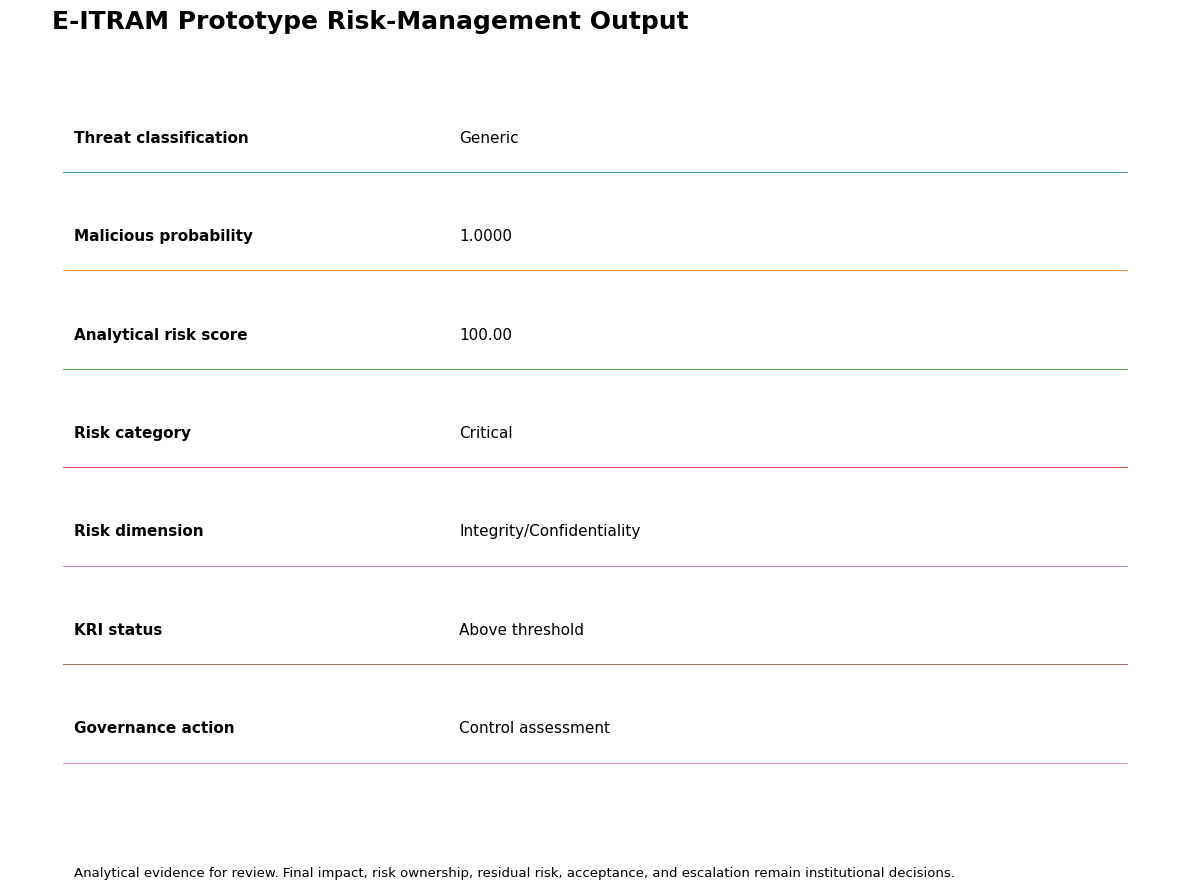

In [ ]:
# Cell 30: Publication-quality E-ITRAM prototype dashboard figure

fig, ax = plt.subplots(figsize=(12, 6.8))
ax.axis("off")

ax.text(
    0.02, 0.96,
    "E-ITRAM Prototype Risk-Management Output",
    fontsize=18,
    fontweight="bold",
    va="top",
)

dashboard_items = [
    (
        "Threat classification",
        str(prototype["predicted_attack_category"]),
    ),
    (
        "Malicious probability",
        f'{prototype["predicted_malicious_probability"]:.4f}',
    ),
    (
        "Analytical risk score",
        f'{prototype["analytical_risk_score"]:.2f}',
    ),
    (
        "Risk category",
        str(prototype["risk_category"]),
    ),
    (
        "Risk dimension",
        str(prototype["risk_dimension"]),
    ),
    (
        "KRI status",
        str(prototype["risk_appetite_status"]),
    ),
    (
        "Governance action",
        str(prototype["governance_action"]),
    ),
]

y = 0.83

for key, value in dashboard_items:
    ax.text(
        0.04, y, key,
        fontsize=11,
        fontweight="bold",
        va="center",
    )
    ax.text(
        0.38, y, value,
        fontsize=11,
        va="center",
    )
    ax.plot(
        [0.03, 0.97],
        [y - 0.035, y - 0.035],
        linewidth=0.6,
    )
    y -= 0.10

ax.text(
    0.04, 0.08,
    "Analytical evidence for review. Final impact, risk ownership, "
    "residual risk, acceptance, and escalation remain institutional decisions.",
    fontsize=9.5,
    wrap=True,
)

fig.tight_layout()
save_publication_figure(
    fig,
    "Figure_12_EITRAM_prototype_dashboard",
)
plt.show()
plt.close(fig)

In [ ]:
# Cell 31: Save reusable deployment artifacts

import sklearn

artifact = {
    "selected_model_name": SELECTED_MODEL_NAME,
    "selected_model": selected_model,
    "selected_preprocessor": selected_prep,
    "multi_model": multi_final,
    "multi_preprocessor": multi_prep_full,
    "multi_encoder": multi_encoder,
    "feature_columns": FEATURE_COLUMNS,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "risk_mapping": risk_mapping,
    "default_impact_factor": DEFAULT_IMPACT_FACTOR,
    "risk_appetite_threshold": RISK_APPETITE_THRESHOLD,
    "risk_bands": RISK_BANDS,
    "seed": SEED,
    "versions": versions,
}

joblib.dump(
    artifact,
    ARTIFACT_DIR / "EITRAM_artifacts.joblib",
    compress=3,
)

joblib.dump(
    selected_model,
    ARTIFACT_DIR / "selected_binary_model.joblib",
    compress=3,
)

joblib.dump(
    selected_prep,
    ARTIFACT_DIR / "selected_binary_preprocessor.joblib",
    compress=3,
)

joblib.dump(
    multi_final,
    ARTIFACT_DIR / "multiclass_model.joblib",
    compress=3,
)

joblib.dump(
    multi_prep_full,
    ARTIFACT_DIR / "multiclass_preprocessor.joblib",
    compress=3,
)

joblib.dump(
    multi_encoder,
    ARTIFACT_DIR / "multiclass_label_encoder.joblib",
    compress=3,
)

deployment_config = {
    "selected_model_name": SELECTED_MODEL_NAME,
    "feature_columns": FEATURE_COLUMNS,
    "risk_mapping": risk_mapping.to_dict(orient="records"),
    "default_impact_factor": DEFAULT_IMPACT_FACTOR,
    "risk_appetite_threshold": RISK_APPETITE_THRESHOLD,
    "risk_bands": RISK_BANDS,
}

with open(
    ARTIFACT_DIR / "deployment_config.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(deployment_config, handle, indent=2)

print("Deployment artifacts written to:")
print(ARTIFACT_DIR)

Deployment artifacts written to:
/content/E_ITRAM/artifacts


In [37]:
# ============================================================
# INSTALL STREAMLIT DEPENDENCIES
# ============================================================

%pip install -q --disable-pip-version-check \
    "streamlit>=1.40,<2.0" \
    "numpy==2.1.3" \
    "pandas==2.2.3" \
    "scipy==1.14.1" \
    "scikit-learn==1.6.1" \
    "xgboost==2.1.4" \
    "shap==0.46.0" \
    "lime==0.2.0.1" \
    "joblib==1.4.2" \
    "openpyxl==3.1.5"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 27.6 MB/s eta 0:00:00


In [42]:
# ============================================================
# ZIP THE COMPLETE E-ITRAM FOLDER AND DOWNLOAD IT
# ============================================================

import os
import shutil
from google.colab import files

# Folder to compress
SOURCE_FOLDER = "/content/E_ITRAM"

# Output ZIP file
ZIP_FILE = "/content/E_ITRAM_submission_package"

# Check that the folder exists
if not os.path.exists(SOURCE_FOLDER):
    raise FileNotFoundError(
        f"Folder not found: {SOURCE_FOLDER}\n"
        "Please check the folder name and location."
    )

# Remove an old ZIP if it already exists
old_zip = ZIP_FILE + ".zip"
if os.path.exists(old_zip):
    os.remove(old_zip)

# Create ZIP archive
created_zip = shutil.make_archive(
    ZIP_FILE,
    "zip",
    root_dir="/content",
    base_dir="E_ITRAM"
)

# Display information
size_mb = os.path.getsize(created_zip) / (1024 ** 2)

print("=" * 70)
print("ZIP CREATION COMPLETED")
print("=" * 70)
print(f"Source folder : {SOURCE_FOLDER}")
print(f"ZIP file      : {created_zip}")
print(f"ZIP size      : {size_mb:.2f} MB")
print("=" * 70)

# Download automatically to your computer
files.download(created_zip)

ZIP CREATION COMPLETED
Source folder : /content/E_ITRAM
ZIP file      : /content/E_ITRAM_submission_package.zip
ZIP size      : 30.70 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# E-ITRAM
# COMBINE ALL GENERATED TABLES AND FIGURES INTO ONE PDF
# FOR EVALUATION
# ============================================================

# ------------------------------------------------------------
# 1. INSTALL / IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------

%pip install -q --disable-pip-version-check reportlab openpyxl pillow pandas

import os
import re
import math
import shutil
from pathlib import Path

import pandas as pd
from PIL import Image

from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch, mm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image as RLImage,
    Table,
    TableStyle,
    PageBreak,
    KeepTogether,
)
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfbase import pdfmetrics


# ------------------------------------------------------------
# 2. PROJECT DIRECTORIES
# ------------------------------------------------------------

ROOT = Path("/content/E_ITRAM")

FIG_DIR = ROOT / "figures"
TABLE_DIR = ROOT / "tables"
REPORT_DIR = ROOT / "reports"
ARTIFACT_DIR = ROOT / "artifacts"

OUTPUT_DIR = ROOT / "evaluation_pdf"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PDF = OUTPUT_DIR / "E_ITRAM_Complete_Tables_and_Figures_Evaluation.pdf"


# ------------------------------------------------------------
# 3. VERIFY PROJECT EXISTS
# ------------------------------------------------------------

if not ROOT.exists():
    raise FileNotFoundError(
        f"E-ITRAM project folder was not found:\n{ROOT}\n\n"
        "Please run the complete E-ITRAM notebook first."
    )

print("=" * 80)
print("E-ITRAM TABLE AND FIGURE PDF GENERATOR")
print("=" * 80)
print(f"Project folder: {ROOT}")
print()


# ------------------------------------------------------------
# 4. CREATE PDF STYLES
# ------------------------------------------------------------

styles = getSampleStyleSheet()

TITLE_STYLE = ParagraphStyle(
    "EITRAMTitle",
    parent=styles["Title"],
    fontName="Helvetica-Bold",
    fontSize=20,
    leading=25,
    alignment=TA_CENTER,
    spaceAfter=18,
)

SUBTITLE_STYLE = ParagraphStyle(
    "EITRAMSubtitle",
    parent=styles["Normal"],
    fontName="Helvetica",
    fontSize=11,
    leading=15,
    alignment=TA_CENTER,
    spaceAfter=8,
)

SECTION_STYLE = ParagraphStyle(
    "EITRAMSection",
    parent=styles["Heading1"],
    fontName="Helvetica-Bold",
    fontSize=15,
    leading=19,
    alignment=TA_LEFT,
    spaceBefore=8,
    spaceAfter=12,
)

SUBSECTION_STYLE = ParagraphStyle(
    "EITRAMSubsection",
    parent=styles["Heading2"],
    fontName="Helvetica-Bold",
    fontSize=12,
    leading=15,
    spaceBefore=6,
    spaceAfter=8,
)

CAPTION_STYLE = ParagraphStyle(
    "EITRAMCaption",
    parent=styles["Normal"],
    fontName="Helvetica",
    fontSize=9,
    leading=12,
    alignment=TA_CENTER,
    spaceBefore=5,
    spaceAfter=12,
)

NORMAL_STYLE = ParagraphStyle(
    "EITRAMNormal",
    parent=styles["Normal"],
    fontName="Helvetica",
    fontSize=9.5,
    leading=13,
    spaceAfter=6,
)

SMALL_STYLE = ParagraphStyle(
    "EITRAMSmall",
    parent=styles["Normal"],
    fontName="Helvetica",
    fontSize=7.5,
    leading=9,
)


# ------------------------------------------------------------
# 5. HELPER: CLEAN DISPLAY NAME
# ------------------------------------------------------------

def clean_name(filename):
    """
    Convert technical filenames into publication-style titles.
    """
    name = Path(filename).stem

    replacements = {
        "_": " ",
        "-": " ",
        "EITRAM": "E-ITRAM",
        "eitram": "E-ITRAM",
        "ROC": "ROC",
        "PR": "PR",
        "SHAP": "SHAP",
        "LIME": "LIME",
        "KRI": "KRI",
        "McNemar": "McNemar",
    }

    for old, new in replacements.items():
        name = name.replace(old, new)

    name = re.sub(r"\s+", " ", name).strip()

    return name


# ------------------------------------------------------------
# 6. DISCOVER ALL FILES
# ------------------------------------------------------------

print("Scanning generated E-ITRAM outputs...")

image_files = []
table_files = []
report_files = []

if FIG_DIR.exists():
    for p in FIG_DIR.rglob("*"):
        if p.is_file() and p.suffix.lower() in {
            ".png", ".jpg", ".jpeg", ".webp"
        }:
            image_files.append(p)

if TABLE_DIR.exists():
    for p in TABLE_DIR.rglob("*"):
        if p.is_file() and p.suffix.lower() in {
            ".csv", ".xlsx", ".xls"
        }:
            table_files.append(p)

if REPORT_DIR.exists():
    for p in REPORT_DIR.rglob("*"):
        if p.is_file() and p.suffix.lower() in {
            ".csv", ".xlsx", ".xls", ".txt"
        }:
            report_files.append(p)


# ------------------------------------------------------------
# 7. REMOVE DUPLICATES
# ------------------------------------------------------------

image_files = sorted(
    list(dict.fromkeys(image_files)),
    key=lambda x: str(x).lower()
)

table_files = sorted(
    list(dict.fromkeys(table_files)),
    key=lambda x: str(x).lower()
)

report_files = sorted(
    list(dict.fromkeys(report_files)),
    key=lambda x: str(x).lower()
)


print(f"Figures found : {len(image_files)}")
print(f"Tables found  : {len(table_files)}")
print(f"Reports found : {len(report_files)}")
print()


# ------------------------------------------------------------
# 8. CREATE PUBLICATION-STYLE FIGURE ORDER
# ------------------------------------------------------------

def figure_sort_key(path):
    """
    Prefer numerical figure ordering when filenames contain
    figure numbers.
    """

    name = path.stem.lower()

    match = re.search(
        r"(?:figure|fig)[_\-\s]*(\d+)",
        name
    )

    if match:
        return (
            0,
            int(match.group(1)),
            name
        )

    # Architecture first
    if "architecture" in name:
        return (0, 0, name)

    # Then alphabetically
    return (1, 9999, name)


image_files = sorted(
    image_files,
    key=figure_sort_key
)


# ------------------------------------------------------------
# 9. TABLE ORDER
# ------------------------------------------------------------

def table_sort_key(path):
    name = path.stem.lower()

    match = re.search(
        r"(?:table|tbl)[_\-\s]*(\d+)",
        name
    )

    if match:
        return (
            0,
            int(match.group(1)),
            name
        )

    return (1, 9999, name)


table_files = sorted(
    table_files,
    key=table_sort_key
)


# ------------------------------------------------------------
# 10. PAGE HEADER / FOOTER
# ------------------------------------------------------------

def add_page_number(canvas, doc):

    canvas.saveState()

    width, height = doc.pagesize

    # Header
    canvas.setFont("Helvetica-Bold", 8)
    canvas.drawString(
        18 * mm,
        height - 12 * mm,
        "E-ITRAM Evaluation Evidence"
    )

    # Footer
    canvas.setFont("Helvetica", 8)

    canvas.drawCentredString(
        width / 2,
        9 * mm,
        f"Page {doc.page}"
    )

    canvas.restoreState()


# ------------------------------------------------------------
# 11. CREATE PDF DOCUMENT
# ------------------------------------------------------------

doc = SimpleDocTemplate(
    str(OUTPUT_PDF),
    pagesize=A4,
    rightMargin=15 * mm,
    leftMargin=15 * mm,
    topMargin=18 * mm,
    bottomMargin=16 * mm,
    title="E-ITRAM Complete Tables and Figures for Evaluation",
    author="E-ITRAM Research Project",
)


story = []


# ------------------------------------------------------------
# 12. COVER PAGE
# ------------------------------------------------------------

story.append(Spacer(1, 35 * mm))

story.append(
    Paragraph(
        "E-ITRAM",
        TITLE_STYLE
    )
)

story.append(
    Paragraph(
        "Explainable IT Risk Assessment and Management Framework",
        SUBTITLE_STYLE
    )
)

story.append(Spacer(1, 8 * mm))

story.append(
    Paragraph(
        "Complete Tables, Figures, and Evaluation Evidence",
        ParagraphStyle(
            "Cover2",
            parent=SUBTITLE_STYLE,
            fontName="Helvetica-Bold",
            fontSize=13,
        )
    )
)

story.append(Spacer(1, 15 * mm))

story.append(
    Paragraph(
        "Prepared from the outputs generated by the complete "
        "E-ITRAM Google Colab implementation.",
        NORMAL_STYLE
    )
)

story.append(Spacer(1, 8 * mm))

story.append(
    Paragraph(
        f"Figures collected: {len(image_files)}",
        NORMAL_STYLE
    )
)

story.append(
    Paragraph(
        f"Tables collected: {len(table_files)}",
        NORMAL_STYLE
    )
)

story.append(
    Paragraph(
        f"Evaluation reports collected: {len(report_files)}",
        NORMAL_STYLE
    )
)

story.append(Spacer(1, 15 * mm))

story.append(
    Paragraph(
        "This document is intended as a consolidated evaluation artifact "
        "for inspection of the computational and visual evidence generated "
        "by the E-ITRAM implementation.",
        NORMAL_STYLE
    )
)

story.append(PageBreak())


# ------------------------------------------------------------
# 13. CONTENT INVENTORY
# ------------------------------------------------------------

story.append(
    Paragraph(
        "1. Evaluation Evidence Inventory",
        SECTION_STYLE
    )
)

story.append(
    Paragraph(
        "The following sections contain the tables, figures, and "
        "evaluation outputs generated by the E-ITRAM implementation.",
        NORMAL_STYLE
    )
)

inventory_data = [
    [
        Paragraph("<b>Evidence Type</b>", SMALL_STYLE),
        Paragraph("<b>Number of Items</b>", SMALL_STYLE),
    ],
    [
        Paragraph("Figures", SMALL_STYLE),
        Paragraph(str(len(image_files)), SMALL_STYLE),
    ],
    [
        Paragraph("Tables", SMALL_STYLE),
        Paragraph(str(len(table_files)), SMALL_STYLE),
    ],
    [
        Paragraph("Evaluation Reports", SMALL_STYLE),
        Paragraph(str(len(report_files)), SMALL_STYLE),
    ],
]

inventory_table = Table(
    inventory_data,
    colWidths=[100 * mm, 45 * mm],
    repeatRows=1,
)

inventory_table.setStyle(
    TableStyle([
        ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("ALIGN", (1, 1), (1, -1), "CENTER"),
        ("LEFTPADDING", (0, 0), (-1, -1), 5),
        ("RIGHTPADDING", (0, 0), (-1, -1), 5),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
    ])
)

story.append(inventory_table)
story.append(PageBreak())


# ------------------------------------------------------------
# 14. ADD TABLES
# ------------------------------------------------------------

if table_files:

    story.append(
        Paragraph(
            "2. Tables",
            SECTION_STYLE
        )
    )

    for index, table_path in enumerate(table_files, start=1):

        display_title = clean_name(table_path.name)

        story.append(
            Paragraph(
                f"Table {index}. {display_title}",
                SUBSECTION_STYLE
            )
        )

        try:

            if table_path.suffix.lower() == ".csv":
                df = pd.read_csv(table_path)

            elif table_path.suffix.lower() in {".xlsx", ".xls"}:
                excel = pd.ExcelFile(table_path)

                # Read first sheet by default
                df = pd.read_excel(
                    table_path,
                    sheet_name=excel.sheet_names[0]
                )

            else:
                continue

            # Replace missing values
            df = df.fillna("")

            # Convert everything to string
            df = df.astype(str)

            # Limit extremely long text to maintain PDF readability
            def shorten(value, max_chars=45):
                value = str(value)

                if len(value) > max_chars:
                    return value[:max_chars - 3] + "..."

                return value

            df_display = df.applymap(shorten)

            data = []

            # Header
            header = []

            for column in df_display.columns:
                header.append(
                    Paragraph(
                        f"<b>{shorten(column, 35)}</b>",
                        SMALL_STYLE
                    )
                )

            data.append(header)

            # Rows
            for _, row in df_display.iterrows():

                data.append([
                    Paragraph(
                        shorten(value, 45),
                        SMALL_STYLE
                    )
                    for value in row.tolist()
                ])

            # Determine column widths
            ncols = len(df_display.columns)

            if ncols <= 5:
                available_width = 175 * mm
                col_width = available_width / max(ncols, 1)
                col_widths = [col_width] * ncols

            else:
                col_width = 175 * mm / ncols
                col_widths = [col_width] * ncols

            table = Table(
                data,
                colWidths=col_widths,
                repeatRows=1,
                splitByRow=1,
            )

            table.setStyle(
                TableStyle([
                    (
                        "GRID",
                        (0, 0),
                        (-1, -1),
                        0.35,
                        colors.black
                    ),
                    (
                        "BACKGROUND",
                        (0, 0),
                        (-1, 0),
                        colors.lightgrey
                    ),
                    (
                        "VALIGN",
                        (0, 0),
                        (-1, -1),
                        "MIDDLE"
                    ),
                    (
                        "ALIGN",
                        (0, 0),
                        (-1, -1),
                        "LEFT"
                    ),
                    (
                        "LEFTPADDING",
                        (0, 0),
                        (-1, -1),
                        3
                    ),
                    (
                        "RIGHTPADDING",
                        (0, 0),
                        (-1, -1),
                        3
                    ),
                    (
                        "TOPPADDING",
                        (0, 0),
                        (-1, -1),
                        3
                    ),
                    (
                        "BOTTOMPADDING",
                        (0, 0),
                        (-1, -1),
                        3
                    ),
                ])
            )

            story.append(table)

            story.append(
                Paragraph(
                    f"Source file: {table_path.name}",
                    CAPTION_STYLE
                )
            )

            story.append(PageBreak())

        except Exception as e:

            story.append(
                Paragraph(
                    f"Unable to render table: {table_path.name}",
                    NORMAL_STYLE
                )
            )

            story.append(
                Paragraph(
                    f"Reason: {str(e)}",
                    SMALL_STYLE
                )
            )

            story.append(PageBreak())


else:

    story.append(
        Paragraph(
            "2. Tables",
            SECTION_STYLE
        )
    )

    story.append(
        Paragraph(
            "No CSV/XLSX tables were found in the generated tables directory.",
            NORMAL_STYLE
        )
    )

    story.append(PageBreak())


# ------------------------------------------------------------
# 15. ADD FIGURES
# ------------------------------------------------------------

story.append(
    Paragraph(
        "3. Figures",
        SECTION_STYLE
    )
)

if image_files:

    for index, image_path in enumerate(image_files, start=1):

        display_title = clean_name(image_path.name)

        story.append(
            Paragraph(
                f"Figure {index}. {display_title}",
                SUBSECTION_STYLE
            )
        )

        try:

            with Image.open(image_path) as img:

                width_px, height_px = img.size

                # Maintain original aspect ratio
                aspect = height_px / width_px

                max_width = 175 * mm
                max_height = 235 * mm

                display_width = max_width
                display_height = display_width * aspect

                if display_height > max_height:
                    display_height = max_height
                    display_width = display_height / aspect

            rl_img = RLImage(
                str(image_path),
                width=display_width,
                height=display_height,
            )

            rl_img.hAlign = "CENTER"

            story.append(rl_img)

            story.append(
                Paragraph(
                    f"Source file: {image_path.name} | "
                    f"Resolution: {width_px} × {height_px} pixels",
                    CAPTION_STYLE
                )
            )

        except Exception as e:

            story.append(
                Paragraph(
                    f"Unable to render figure: {image_path.name}",
                    NORMAL_STYLE
                )
            )

            story.append(
                Paragraph(
                    f"Reason: {str(e)}",
                    SMALL_STYLE
                )
            )

        story.append(PageBreak())


else:

    story.append(
        Paragraph(
            "No generated figure files were found.",
            NORMAL_STYLE
        )
    )

    story.append(PageBreak())


# ------------------------------------------------------------
# 16. ADD TEXT REPORTS
# ------------------------------------------------------------

if report_files:

    story.append(
        Paragraph(
            "4. Evaluation Reports",
            SECTION_STYLE
        )
    )

    for report_path in report_files:

        if report_path.suffix.lower() != ".txt":
            continue

        story.append(
            Paragraph(
                clean_name(report_path.name),
                SUBSECTION_STYLE
            )
        )

        try:

            text = report_path.read_text(
                encoding="utf-8",
                errors="replace"
            )

            # Prevent pathological PDF size
            text = text[:100000]

            for line in text.splitlines():

                line = line.strip()

                if not line:
                    story.append(Spacer(1, 3))
                    continue

                safe_line = (
                    line
                    .replace("&", "&amp;")
                    .replace("<", "&lt;")
                    .replace(">", "&gt;")
                )

                story.append(
                    Paragraph(
                        safe_line,
                        SMALL_STYLE
                    )
                )

            story.append(PageBreak())

        except Exception as e:

            story.append(
                Paragraph(
                    f"Unable to read report: {report_path.name}",
                    NORMAL_STYLE
                )
            )

            story.append(
                Paragraph(
                    str(e),
                    SMALL_STYLE
                )
            )

            story.append(PageBreak())


# ------------------------------------------------------------
# 17. BUILD PDF
# ------------------------------------------------------------

print()
print("Building consolidated PDF...")
print()

doc.build(
    story,
    onFirstPage=add_page_number,
    onLaterPages=add_page_number,
)


# ------------------------------------------------------------
# 18. VERIFY PDF
# ------------------------------------------------------------

if not OUTPUT_PDF.exists():
    raise RuntimeError(
        "PDF generation failed. Output file was not created."
    )

pdf_size_mb = OUTPUT_PDF.stat().st_size / (1024 ** 2)


print("=" * 80)
print("PDF GENERATION COMPLETED SUCCESSFULLY")
print("=" * 80)
print(f"Output PDF : {OUTPUT_PDF}")
print(f"Size       : {pdf_size_mb:.2f} MB")
print(f"Figures    : {len(image_files)}")
print(f"Tables     : {len(table_files)}")
print(f"Reports    : {len(report_files)}")
print("=" * 80)


# ------------------------------------------------------------
# 19. DOWNLOAD AUTOMATICALLY
# ------------------------------------------------------------

from google.colab import files

files.download(str(OUTPUT_PDF))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.4 MB/s eta 0:00:00
E-ITRAM TABLE AND FIGURE PDF GENERATOR
Project folder: /content/E_ITRAM

Scanning generated E-ITRAM outputs...
Figures found : 0
Tables found  : 19
Reports found : 2


Building consolidated PDF...

PDF GENERATION COMPLETED SUCCESSFULLY
Output PDF : /content/E_ITRAM/evaluation_pdf/E_ITRAM_Complete_Tables_and_Figures_Evaluation.pdf
Size       : 0.05 MB
Figures    : 0
Tables     : 19
Reports    : 2


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
# ============================================================
# E-ITRAM
# EXPLAINABLE IT RISK ASSESSMENT AND MANAGEMENT
# COMPLETE STREAMLIT WEB APPLICATION
#
# Designed for the artifacts generated by the E-ITRAM
# Google Colab implementation.
# ============================================================

from __future__ import annotations

import json
import math
import os
import sys
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import streamlit as st

# Optional ML/explainability packages
try:
    import shap
except Exception:
    shap = None

try:
    from lime.lime_tabular import LimeTabularExplainer
except Exception:
    LimeTabularExplainer = None


# ============================================================
# 1. PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="E-ITRAM | IT Risk Assessment",
    page_icon="🛡️",
    layout="wide",
    initial_sidebar_state="expanded",
)


# ============================================================
# 2. GLOBAL CONFIGURATION
# ============================================================

APP_TITLE = "E-ITRAM"
APP_SUBTITLE = "Explainable IT Risk Assessment and Management Framework"

DEFAULT_ROOT = Path(
    os.environ.get(
        "EITRAM_ROOT",
        "/content/E_ITRAM"
    )
)

ARTIFACT_DIR = DEFAULT_ROOT / "artifacts"
FIGURE_DIR = DEFAULT_ROOT / "figures"
TABLE_DIR = DEFAULT_ROOT / "tables"
REPORT_DIR = DEFAULT_ROOT / "reports"

RISK_BANDS = {
    "Low": (0.0, 24.999999),
    "Moderate": (25.0, 49.999999),
    "High": (50.0, 74.999999),
    "Critical": (75.0, 100.0),
}

DEFAULT_IMPACT = 1.0
DEFAULT_RISK_THRESHOLD = 50.0


# ============================================================
# 3. CUSTOM CSS
# ============================================================

st.markdown(
    """
    <style>

    .main-title {
        font-size: 2.25rem;
        font-weight: 700;
        margin-bottom: 0.15rem;
    }

    .main-subtitle {
        font-size: 1.05rem;
        color: #666666;
        margin-bottom: 1.2rem;
    }

    .risk-card {
        padding: 1.0rem;
        border-radius: 0.6rem;
        border: 1px solid #dddddd;
        background-color: #fafafa;
        text-align: center;
        margin-bottom: 0.8rem;
    }

    .metric-card {
        padding: 0.8rem;
        border-radius: 0.5rem;
        border: 1px solid #dddddd;
        background-color: #ffffff;
    }

    .small-note {
        color: #666666;
        font-size: 0.85rem;
    }

    .section-title {
        font-size: 1.35rem;
        font-weight: 650;
        margin-top: 1rem;
        margin-bottom: 0.5rem;
    }

    </style>
    """,
    unsafe_allow_html=True,
)


# ============================================================
# 4. UTILITY FUNCTIONS
# ============================================================

def safe_float(value: Any, default: float = 0.0) -> float:
    """Convert a value safely to float."""

    try:
        result = float(value)

        if not math.isfinite(result):
            return default

        return result

    except Exception:
        return default


def normalize_probability(value: Any) -> float:
    """Force probability into [0, 1]."""

    value = safe_float(value)

    if value > 1.0 and value <= 100.0:
        value = value / 100.0

    return float(np.clip(value, 0.0, 1.0))


def risk_band(score: float) -> str:
    """Map 0-100 risk score to E-ITRAM risk band."""

    score = float(np.clip(score, 0.0, 100.0))

    if score < 25:
        return "Low"

    if score < 50:
        return "Moderate"

    if score < 75:
        return "High"

    return "Critical"


def risk_level_message(band: str) -> str:

    messages = {
        "Low": "Risk is within the low-risk range.",
        "Moderate": "Risk requires monitoring and documented management.",
        "High": "Risk exceeds the normal tolerance range and requires management attention.",
        "Critical": "Risk is critically elevated and requires immediate management attention.",
    }

    return messages.get(
        band,
        "Risk level requires assessment."
    )


def format_percent(value: float) -> str:
    return f"{100.0 * safe_float(value):.2f}%"


def format_score(value: float) -> str:
    return f"{safe_float(value):.2f}"


# ============================================================
# 5. FILE VALIDATION
# ============================================================

def required_artifacts() -> Dict[str, Path]:

    return {
        "Combined artifacts": ARTIFACT_DIR / "EITRAM_artifacts.joblib",
        "Selected binary model": ARTIFACT_DIR / "selected_binary_model.joblib",
        "Selected binary preprocessor": ARTIFACT_DIR / "selected_binary_preprocessor.joblib",
        "Multiclass model": ARTIFACT_DIR / "multiclass_model.joblib",
        "Multiclass preprocessor": ARTIFACT_DIR / "multiclass_preprocessor.joblib",
        "Multiclass label encoder": ARTIFACT_DIR / "multiclass_label_encoder.joblib",
        "Deployment configuration": ARTIFACT_DIR / "deployment_config.json",
    }


def check_artifacts() -> Tuple[bool, Dict[str, bool]]:

    statuses = {}

    for name, path in required_artifacts().items():
        statuses[name] = path.exists()

    # Core binary artifacts are required for detection.
    core = [
        "Selected binary model",
        "Selected binary preprocessor",
    ]

    core_ok = all(statuses.get(x, False) for x in core)

    return core_ok, statuses


# ============================================================
# 6. LOAD CONFIGURATION
# ============================================================

@st.cache_data(show_spinner=False)
def load_config() -> Dict[str, Any]:

    path = ARTIFACT_DIR / "deployment_config.json"

    if not path.exists():
        return {
            "risk_appetite_threshold": DEFAULT_RISK_THRESHOLD,
            "default_impact_factor": DEFAULT_IMPACT,
            "risk_bands": RISK_BANDS,
        }

    try:

        with open(path, "r", encoding="utf-8") as f:
            config = json.load(f)

        if not isinstance(config, dict):
            config = {}

        return config

    except Exception:
        return {
            "risk_appetite_threshold": DEFAULT_RISK_THRESHOLD,
            "default_impact_factor": DEFAULT_IMPACT,
            "risk_bands": RISK_BANDS,
        }


CONFIG = load_config()

RISK_THRESHOLD = safe_float(
    CONFIG.get(
        "risk_appetite_threshold",
        DEFAULT_RISK_THRESHOLD
    ),
    DEFAULT_RISK_THRESHOLD,
)

DEFAULT_IMPACT = safe_float(
    CONFIG.get(
        "default_impact_factor",
        1.0
    ),
    1.0,
)


# ============================================================
# 7. LOAD MODELS
# ============================================================

@st.cache_resource(show_spinner=False)
def load_binary_model():

    path = ARTIFACT_DIR / "selected_binary_model.joblib"

    if not path.exists():
        return None

    return joblib.load(path)


@st.cache_resource(show_spinner=False)
def load_binary_preprocessor():

    path = ARTIFACT_DIR / "selected_binary_preprocessor.joblib"

    if not path.exists():
        return None

    return joblib.load(path)


@st.cache_resource(show_spinner=False)
def load_multiclass_model():

    path = ARTIFACT_DIR / "multiclass_model.joblib"

    if not path.exists():
        return None

    return joblib.load(path)


@st.cache_resource(show_spinner=False)
def load_multiclass_preprocessor():

    path = ARTIFACT_DIR / "multiclass_preprocessor.joblib"

    if not path.exists():
        return None

    return joblib.load(path)


@st.cache_resource(show_spinner=False)
def load_label_encoder():

    path = ARTIFACT_DIR / "multiclass_label_encoder.joblib"

    if not path.exists():
        return None

    return joblib.load(path)


@st.cache_resource(show_spinner=False)
def load_combined_artifacts():

    path = ARTIFACT_DIR / "EITRAM_artifacts.joblib"

    if not path.exists():
        return None

    try:
        return joblib.load(path)

    except Exception:
        return None


# ============================================================
# 8. LOAD ALL AVAILABLE ARTIFACTS
# ============================================================

CORE_READY, ARTIFACT_STATUS = check_artifacts()

BINARY_MODEL = None
BINARY_PREPROCESSOR = None
MULTICLASS_MODEL = None
MULTICLASS_PREPROCESSOR = None
LABEL_ENCODER = None
COMBINED_ARTIFACTS = None

if CORE_READY:

    try:
        BINARY_MODEL = load_binary_model()
        BINARY_PREPROCESSOR = load_binary_preprocessor()

    except Exception as exc:

        BINARY_MODEL = None
        BINARY_PREPROCESSOR = None

        st.session_state["binary_load_error"] = str(exc)

try:
    MULTICLASS_MODEL = load_multiclass_model()
except Exception:
    MULTICLASS_MODEL = None

try:
    MULTICLASS_PREPROCESSOR = load_multiclass_preprocessor()
except Exception:
    MULTICLASS_PREPROCESSOR = None

try:
    LABEL_ENCODER = load_label_encoder()
except Exception:
    LABEL_ENCODER = None

try:
    COMBINED_ARTIFACTS = load_combined_artifacts()
except Exception:
    COMBINED_ARTIFACTS = None


# ============================================================
# 9. DETERMINE MODEL FEATURE NAMES
# ============================================================

def get_model_feature_names(
    model: Any,
    preprocessor: Any,
) -> List[str]:

    names = []

    # Try fitted preprocessor first
    if preprocessor is not None:

        try:
            names = list(
                preprocessor.get_feature_names_out()
            )
        except Exception:
            names = []

    # Try model feature names
    if not names and model is not None:

        try:
            names = list(model.feature_names_in_)
        except Exception:
            names = []

    return names


# ============================================================
# 10. DETERMINE RAW INPUT FEATURES
# ============================================================

def get_raw_feature_names() -> List[str]:

    candidates = []

    if COMBINED_ARTIFACTS is not None:

        if isinstance(COMBINED_ARTIFACTS, dict):

            for key in [
                "feature_names",
                "features",
                "predictor_columns",
                "raw_feature_names",
            ]:

                value = COMBINED_ARTIFACTS.get(key)

                if isinstance(value, (list, tuple)):
                    candidates.extend(
                        [str(x) for x in value]
                    )

    if candidates:
        return list(dict.fromkeys(candidates))

    # Recover from preprocessing pipeline
    if BINARY_PREPROCESSOR is not None:

        try:

            transformers = getattr(
                BINARY_PREPROCESSOR,
                "transformers_",
                []
            )

            names = []

            for _, transformer, columns in transformers:

                if transformer == "drop":
                    continue

                if columns is None:
                    continue

                if isinstance(columns, str):
                    names.append(columns)

                else:
                    names.extend(
                        [str(x) for x in columns]
                    )

            if names:
                return list(dict.fromkeys(names))

        except Exception:
            pass

    return []


RAW_FEATURE_NAMES = get_raw_feature_names()


# ============================================================
# 11. PREPROCESS USER DATA
# ============================================================

def prepare_input_dataframe(
    input_df: pd.DataFrame
) -> pd.DataFrame:

    df = input_df.copy()

    # Remove target columns if user uploads a dataset
    target_columns = [
        "label",
        "attack_cat",
        "target",
        "class",
    ]

    for col in target_columns:

        if col in df.columns:
            df = df.drop(columns=[col])

    # Remove obvious identifier
    if "id" in df.columns:
        df = df.drop(columns=["id"])

    return df


def align_features(
    df: pd.DataFrame,
    expected_features: List[str],
) -> pd.DataFrame:

    if not expected_features:
        return df.copy()

    result = df.copy()

    # Add missing columns
    for col in expected_features:

        if col not in result.columns:
            result[col] = np.nan

    # Keep expected order
    result = result[expected_features]

    return result


# ============================================================
# 12. BINARY PREDICTION
# ============================================================

def binary_predict(
    input_df: pd.DataFrame
) -> Tuple[np.ndarray, np.ndarray]:

    if BINARY_MODEL is None:
        raise RuntimeError(
            "Binary model is not available."
        )

    if BINARY_PREPROCESSOR is None:
        raise RuntimeError(
            "Binary preprocessing pipeline is not available."
        )

    df = prepare_input_dataframe(input_df)

    raw_names = RAW_FEATURE_NAMES

    if raw_names:
        df = align_features(
            df,
            raw_names
        )

    transformed = BINARY_PREPROCESSOR.transform(df)

    predictions = BINARY_MODEL.predict(
        transformed
    )

    if hasattr(
        BINARY_MODEL,
        "predict_proba"
    ):

        probabilities = BINARY_MODEL.predict_proba(
            transformed
        )

        if probabilities.ndim == 2 and probabilities.shape[1] >= 2:
            malicious_probability = probabilities[:, 1]

        else:
            malicious_probability = probabilities.ravel()

    elif hasattr(
        BINARY_MODEL,
        "decision_function"
    ):

        decision = BINARY_MODEL.decision_function(
            transformed
        )

        malicious_probability = 1.0 / (
            1.0 + np.exp(-np.asarray(decision))
        )

    else:

        malicious_probability = np.asarray(
            predictions,
            dtype=float
        )

    return (
        np.asarray(predictions),
        np.asarray(malicious_probability),
    )


# ============================================================
# 13. MULTICLASS ATTACK CATEGORY PREDICTION
# ============================================================

def multiclass_predict(
    input_df: pd.DataFrame
) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:

    if (
        MULTICLASS_MODEL is None
        or MULTICLASS_PREPROCESSOR is None
    ):
        return None, None

    df = prepare_input_dataframe(input_df)

    raw_names = RAW_FEATURE_NAMES

    if raw_names:
        df = align_features(
            df,
            raw_names
        )

    transformed = MULTICLASS_PREPROCESSOR.transform(
        df
    )

    predictions = MULTICLASS_MODEL.predict(
        transformed
    )

    probabilities = None

    if hasattr(
        MULTICLASS_MODEL,
        "predict_proba"
    ):

        probabilities = MULTICLASS_MODEL.predict_proba(
            transformed
        )

    labels = predictions

    if LABEL_ENCODER is not None:

        try:

            labels = LABEL_ENCODER.inverse_transform(
                np.asarray(predictions).astype(int)
            )

        except Exception:
            labels = predictions

    return (
        np.asarray(labels),
        probabilities,
    )


# ============================================================
# 14. RISK TRANSLATION
# ============================================================

def calculate_risk(
    malicious_probability: float,
    impact_factor: float,
) -> Dict[str, Any]:

    probability = normalize_probability(
        malicious_probability
    )

    impact = safe_float(
        impact_factor,
        1.0
    )

    impact = float(
        np.clip(
            impact,
            0.0,
            1.0
        )
    )

    risk_score = 100.0 * probability * impact

    risk_score = float(
        np.clip(
            risk_score,
            0.0,
            100.0
        )
    )

    band = risk_band(
        risk_score
    )

    exceeds_appetite = (
        risk_score >= RISK_THRESHOLD
    )

    return {
        "likelihood": probability,
        "impact": impact,
        "risk_score": risk_score,
        "risk_band": band,
        "exceeds_appetite": exceeds_appetite,
    }


# ============================================================
# 15. SHAP EXPLANATION
# ============================================================

def shap_explanation(
    input_df: pd.DataFrame,
    max_features: int = 15,
) -> Optional[pd.DataFrame]:

    if shap is None:
        return None

    if (
        BINARY_MODEL is None
        or BINARY_PREPROCESSOR is None
    ):
        return None

    try:

        df = prepare_input_dataframe(
            input_df
        )

        if RAW_FEATURE_NAMES:
            df = align_features(
                df,
                RAW_FEATURE_NAMES
            )

        transformed = BINARY_PREPROCESSOR.transform(
            df
        )

        feature_names = get_model_feature_names(
            BINARY_MODEL,
            BINARY_PREPROCESSOR,
        )

        if not feature_names:

            feature_names = [
                f"Feature_{i}"
                for i in range(
                    transformed.shape[1]
                )
            ]

        # Limit explanation to first observation
        x = transformed[:1]

        # Linear model
        if hasattr(
            BINARY_MODEL,
            "coef_"
        ):

            explainer = shap.LinearExplainer(
                BINARY_MODEL,
                transformed[:min(
                    100,
                    transformed.shape[0]
                )],
            )

            shap_values = explainer.shap_values(
                x
            )

            if isinstance(
                shap_values,
                list
            ):
                values = np.asarray(
                    shap_values[-1]
                ).reshape(-1)

            else:
                values = np.asarray(
                    shap_values
                ).reshape(-1)

        else:

            explainer = shap.TreeExplainer(
                BINARY_MODEL
            )

            shap_values = explainer.shap_values(
                x
            )

            if isinstance(
                shap_values,
                list
            ):

                values = np.asarray(
                    shap_values[-1]
                ).reshape(-1)

            else:

                values = np.asarray(
                    shap_values
                )

                if values.ndim == 3:
                    values = values[0, :, -1]

                else:
                    values = values.reshape(-1)

        n = min(
            len(feature_names),
            len(values)
        )

        result = pd.DataFrame({
            "Feature": feature_names[:n],
            "SHAP value": values[:n],
        })

        result["Absolute SHAP"] = (
            result["SHAP value"]
            .abs()
        )

        result = result.sort_values(
            "Absolute SHAP",
            ascending=False
        ).head(
            max_features
        )

        result["Direction"] = np.where(
            result["SHAP value"] >= 0,
            "Increases malicious prediction",
            "Decreases malicious prediction",
        )

        return result.reset_index(
            drop=True
        )

    except Exception as exc:

        st.session_state[
            "shap_error"
        ] = str(exc)

        return None


# ============================================================
# 16. LIME EXPLANATION
# ============================================================

def lime_explanation(
    input_df: pd.DataFrame,
) -> Optional[pd.DataFrame]:

    if LimeTabularExplainer is None:
        return None

    if (
        BINARY_MODEL is None
        or BINARY_PREPROCESSOR is None
    ):
        return None

    try:

        df = prepare_input_dataframe(
            input_df
        )

        if RAW_FEATURE_NAMES:
            df = align_features(
                df,
                RAW_FEATURE_NAMES
            )

        transformed = BINARY_PREPROCESSOR.transform(
            df
        )

        feature_names = get_model_feature_names(
            BINARY_MODEL,
            BINARY_PREPROCESSOR,
        )

        if not feature_names:

            feature_names = [
                f"Feature_{i}"
                for i in range(
                    transformed.shape[1]
                )
            ]

        # Create a stable background from current input.
        # LIME needs multiple rows, therefore replicate the
        # observation with a very small numerical perturbation
        # when no training background is available.
        background = np.asarray(
            transformed
        )

        if background.shape[0] == 1:

            background = np.repeat(
                background,
                25,
                axis=0
            )

        def predict_fn(x):

            if hasattr(
                BINARY_MODEL,
                "predict_proba"
            ):

                return BINARY_MODEL.predict_proba(
                    x
                )

            predictions = BINARY_MODEL.predict(
                x
            )

            predictions = np.asarray(
                predictions
            ).astype(float)

            return np.column_stack([
                1.0 - predictions,
                predictions,
            ])

        explainer = LimeTabularExplainer(
            background,
            feature_names=feature_names,
            class_names=[
                "Normal",
                "Malicious",
            ],
            mode="classification",
            discretize_continuous=True,
            random_state=42,
        )

        explanation = explainer.explain_instance(
            np.asarray(
                transformed[0]
            ).ravel(),
            predict_fn,
            num_features=min(
                15,
                len(feature_names)
            ),
        )

        rows = []

        for feature, weight in explanation.as_list():

            rows.append({
                "Feature condition": feature,
                "LIME weight": weight,
                "Direction": (
                    "Malicious"
                    if weight > 0
                    else "Normal"
                ),
            })

        return pd.DataFrame(
            rows
        )

    except Exception as exc:

        st.session_state[
            "lime_error"
        ] = str(exc)

        return None


# ============================================================
# 17. LOAD SAVED TABLES
# ============================================================

@st.cache_data(show_spinner=False)
def discover_tables() -> List[Path]:

    if not TABLE_DIR.exists():
        return []

    return sorted(
        [
            p
            for p in TABLE_DIR.rglob("*")
            if p.is_file()
            and p.suffix.lower()
            in {
                ".csv",
                ".xlsx",
                ".xls",
            }
        ],
        key=lambda p: str(p).lower(),
    )


TABLE_FILES = discover_tables()


def read_table(
    path: Path
) -> Optional[pd.DataFrame]:

    try:

        if path.suffix.lower() == ".csv":
            return pd.read_csv(path)

        if path.suffix.lower() in {
            ".xlsx",
            ".xls",
        }:
            return pd.read_excel(path)

    except Exception:
        return None

    return None


# ============================================================
# 18. LOAD SAVED FIGURES
# ============================================================

@st.cache_data(show_spinner=False)
def discover_figures() -> List[Path]:

    if not FIGURE_DIR.exists():
        return []

    return sorted(
        [
            p
            for p in FIGURE_DIR.rglob("*")
            if p.is_file()
            and p.suffix.lower()
            in {
                ".png",
                ".jpg",
                ".jpeg",
                ".webp",
            }
        ],
        key=lambda p: str(p).lower(),
    )


FIGURE_FILES = discover_figures()


# ============================================================
# 19. SIDEBAR
# ============================================================

with st.sidebar:

    st.markdown(
        "## 🛡️ E-ITRAM"
    )

    st.caption(
        "Explainable IT Risk Assessment and Management"
    )

    st.divider()

    page = st.radio(
        "Navigation",
        [
            "Dashboard",
            "Risk Detection",
            "Explainability",
            "Risk Register",
            "KRI Monitoring",
            "Evaluation Results",
            "Figures & Tables",
            "System Information",
        ],
    )

    st.divider()

    st.markdown(
        "### Configuration"
    )

    st.write(
        f"**Risk appetite:** "
        f"{RISK_THRESHOLD:.2f}"
    )

    st.write(
        f"**Default impact:** "
        f"{DEFAULT_IMPACT:.2f}"
    )

    st.write(
        f"**Figures:** "
        f"{len(FIGURE_FILES)}"
    )

    st.write(
        f"**Tables:** "
        f"{len(TABLE_FILES)}"
    )


# ============================================================
# 20. ARTIFACT WARNING
# ============================================================

if not CORE_READY:

    st.error(
        "The required E-ITRAM binary deployment artifacts "
        "were not found."
    )

    st.markdown(
        """
        ### Required files

        The application expects the following files under:

        `/content/E_ITRAM/artifacts/`

        - `selected_binary_model.joblib`
        - `selected_binary_preprocessor.joblib`

        The complete E-ITRAM notebook must be executed first.
        """
    )

    with st.expander(
        "Artifact status"
    ):

        status_df = pd.DataFrame({
            "Artifact": list(
                ARTIFACT_STATUS.keys()
            ),
            "Available": list(
                ARTIFACT_STATUS.values()
            ),
        })

        st.dataframe(
            status_df,
            use_container_width=True,
            hide_index=True,
        )

    st.stop()


# ============================================================
# 21. APPLICATION HEADER
# ============================================================

st.markdown(
    '<div class="main-title">E-ITRAM</div>',
    unsafe_allow_html=True,
)

st.markdown(
    f'<div class="main-subtitle">{APP_SUBTITLE}</div>',
    unsafe_allow_html=True,
)


# ============================================================
# 22. DASHBOARD
# ============================================================

if page == "Dashboard":

    st.markdown(
        "## Executive Risk Dashboard"
    )

    st.write(
        "The dashboard summarizes the deployed E-ITRAM "
        "risk assessment capability and available evaluation evidence."
    )

    col1, col2, col3, col4 = st.columns(4)

    with col1:

        st.metric(
            "Binary Model",
            "Available"
            if BINARY_MODEL is not None
            else "Unavailable",
        )

    with col2:

        st.metric(
            "Multiclass Model",
            "Available"
            if MULTICLASS_MODEL is not None
            else "Unavailable",
        )

    with col3:

        st.metric(
            "SHAP",
            "Available"
            if shap is not None
            else "Unavailable",
        )

    with col4:

        st.metric(
            "LIME",
            "Available"
            if LimeTabularExplainer is not None
            else "Unavailable",
        )

    st.divider()

    st.markdown(
        "### E-ITRAM Risk Workflow"
    )

    workflow = pd.DataFrame({
        "Stage": [
            "Network/event input",
            "Preprocessing",
            "Binary threat detection",
            "Attack-category classification",
            "Explainability",
            "Risk translation",
            "Risk appetite comparison",
            "KRI / risk register",
            "Management oversight",
        ],
        "Status": [
            "Operational",
            "Operational",
            "Operational",
            "Available"
            if MULTICLASS_MODEL is not None
            else "Not available",
            "Available"
            if shap is not None
            else "Limited",
            "Operational",
            "Operational",
            "Operational",
            "Decision-support",
        ],
    })

    st.dataframe(
        workflow,
        use_container_width=True,
        hide_index=True,
    )

    st.info(
        "The benchmark dataset supports technical threat "
        "detection. Institution-specific financial or business "
        "impact should be supplied by the organization rather "
        "than inferred from UNSW-NB15."
    )


# ============================================================
# 23. RISK DETECTION PAGE
# ============================================================

elif page == "Risk Detection":

    st.markdown(
        "## Risk Detection"
    )

    st.write(
        "Upload a CSV containing network-event predictor variables "
        "compatible with the trained E-ITRAM model."
    )

    uploaded_file = st.file_uploader(
        "Upload network-event CSV",
        type=["csv"],
        key="risk_detection_upload",
    )

    if uploaded_file is not None:

        try:

            input_df = pd.read_csv(
                uploaded_file
            )

            st.success(
                f"Loaded {len(input_df):,} records."
            )

            st.markdown(
                "### Input Preview"
            )

            st.dataframe(
                input_df.head(20),
                use_container_width=True,
                hide_index=True,
            )

            st.markdown(
                "### Impact and Risk Parameters"
            )

            impact = st.slider(
                "Impact factor",
                min_value=0.0,
                max_value=1.0,
                value=float(
                    np.clip(
                        DEFAULT_IMPACT,
                        0.0,
                        1.0,
                    )
                ),
                step=0.01,
                help=(
                    "Institution-defined impact factor. "
                    "This is not inferred from UNSW-NB15."
                ),
            )

            if st.button(
                "Run E-ITRAM Assessment",
                type="primary",
            ):

                with st.spinner(
                    "Running E-ITRAM assessment..."
                ):

                    try:

                        predictions, probabilities = binary_predict(
                            input_df
                        )

                        result_df = input_df.copy()

                        result_df[
                            "Malicious Probability"
                        ] = probabilities

                        result_df[
                            "Detection"
                        ] = np.where(
                            predictions.astype(int) == 1,
                            "Malicious",
                            "Normal",
                        )

                        risk_results = [
                            calculate_risk(
                                probability,
                                impact,
                            )
                            for probability in probabilities
                        ]

                        result_df[
                            "Risk Score"
                        ] = [
                            x["risk_score"]
                            for x in risk_results
                        ]

                        result_df[
                            "Risk Band"
                        ] = [
                            x["risk_band"]
                            for x in risk_results
                        ]

                        result_df[
                            "Exceeds Appetite"
                        ] = [
                            x["exceeds_appetite"]
                            for x in risk_results
                        ]

                        # Multiclass classification
                        try:

                            attack_labels, attack_probabilities = (
                                multiclass_predict(
                                    input_df
                                )
                            )

                            if attack_labels is not None:

                                result_df[
                                    "Attack Category"
                                ] = attack_labels

                        except Exception:
                            pass

                        st.session_state[
                            "latest_results"
                        ] = result_df

                        st.session_state[
                            "latest_input"
                        ] = input_df

                        st.session_state[
                            "latest_impact"
                        ] = impact

                        st.success(
                            "E-ITRAM assessment completed."
                        )

                    except Exception as exc:

                        st.error(
                            "Assessment failed."
                        )

                        st.exception(
                            exc
                        )

            if (
                "latest_results"
                in st.session_state
            ):

                result_df = st.session_state[
                    "latest_results"
                ]

                st.markdown(
                    "### Assessment Results"
                )

                malicious_count = int(
                    (
                        result_df[
                            "Detection"
                        ]
                        == "Malicious"
                    ).sum()
                )

                appetite_count = int(
                    result_df[
                        "Exceeds Appetite"
                    ].sum()
                )

                high_count = int(
                    result_df[
                        "Risk Band"
                    ].isin(
                        [
                            "High",
                            "Critical",
                        ]
                    ).sum()
                )

                c1, c2, c3, c4 = st.columns(4)

                with c1:
                    st.metric(
                        "Events",
                        f"{len(result_df):,}",
                    )

                with c2:
                    st.metric(
                        "Malicious",
                        f"{malicious_count:,}",
                    )

                with c3:
                    st.metric(
                        "High/Critical",
                        f"{high_count:,}",
                    )

                with c4:
                    st.metric(
                        "Above Appetite",
                        f"{appetite_count:,}",
                    )

                st.dataframe(
                    result_df,
                    use_container_width=True,
                    hide_index=True,
                )

                csv_data = result_df.to_csv(
                    index=False
                ).encode(
                    "utf-8"
                )

                st.download_button(
                    "Download Assessment Results",
                    data=csv_data,
                    file_name="E_ITRAM_risk_assessment_results.csv",
                    mime="text/csv",
                )

        except Exception as exc:

            st.error(
                "Unable to read the uploaded CSV."
            )

            st.exception(
                exc
            )

    else:

        st.info(
            "Upload a compatible CSV file to begin risk assessment."
        )


# ============================================================
# 24. EXPLAINABILITY PAGE
# ============================================================

elif page == "Explainability":

    st.markdown(
        "## Explainable AI"
    )

    if (
        "latest_input"
        not in st.session_state
    ):

        st.info(
            "Run a risk assessment first. "
            "The latest assessed event will then be available "
            "for SHAP and LIME explanation."
        )

    else:

        latest_input = st.session_state[
            "latest_input"
        ]

        latest_results = st.session_state.get(
            "latest_results"
        )

        st.markdown(
            "### Select Event"
        )

        event_index = st.number_input(
            "Event row",
            min_value=0,
            max_value=max(
                0,
                len(latest_input) - 1
            ),
            value=0,
            step=1,
        )

        event = latest_input.iloc[
            [event_index]
        ].copy()

        st.markdown(
            "### Selected Event"
        )

        st.dataframe(
            event,
            use_container_width=True,
            hide_index=True,
        )

        if latest_results is not None:

            selected_result = latest_results.iloc[
                event_index
            ]

            col1, col2, col3 = st.columns(3)

            with col1:

                st.metric(
                    "Malicious Probability",
                    format_percent(
                        selected_result[
                            "Malicious Probability"
                        ]
                    ),
                )

            with col2:

                st.metric(
                    "Risk Score",
                    format_score(
                        selected_result[
                            "Risk Score"
                        ]
                    ),
                )

            with col3:

                st.metric(
                    "Risk Band",
                    str(
                        selected_result[
                            "Risk Band"
                        ]
                    ),
                )

        st.divider()

        tab1, tab2 = st.tabs([
            "SHAP",
            "LIME",
        ])

        with tab1:

            if shap is None:

                st.warning(
                    "SHAP is not installed in the current environment."
                )

            else:

                with st.spinner(
                    "Calculating SHAP explanation..."
                ):

                    shap_df = shap_explanation(
                        event
                    )

                if shap_df is not None:

                    st.markdown(
                        "#### Local SHAP Explanation"
                    )

                    st.dataframe(
                        shap_df,
                        use_container_width=True,
                        hide_index=True,
                    )

                    chart_df = (
                        shap_df
                        .set_index("Feature")[
                            ["SHAP value"]
                        ]
                    )

                    st.bar_chart(
                        chart_df
                    )

                    st.caption(
                        "Positive SHAP values support the malicious "
                        "prediction; negative values move the prediction "
                        "toward the normal class."
                    )

                else:

                    st.warning(
                        "SHAP explanation could not be generated "
                        "for this event."
                    )

        with tab2:

            if LimeTabularExplainer is None:

                st.warning(
                    "LIME is not installed in the current environment."
                )

            else:

                with st.spinner(
                    "Calculating LIME explanation..."
                ):

                    lime_df = lime_explanation(
                        event
                    )

                if lime_df is not None:

                    st.markdown(
                        "#### Local LIME Explanation"
                    )

                    st.dataframe(
                        lime_df,
                        use_container_width=True,
                        hide_index=True,
                    )

                    chart_df = (
                        lime_df
                        .set_index(
                            "Feature condition"
                        )[["LIME weight"]]
                    )

                    st.bar_chart(
                        chart_df
                    )

                else:

                    st.warning(
                        "LIME explanation could not be generated."
                    )


# ============================================================
# 25. RISK REGISTER PAGE
# ============================================================

elif page == "Risk Register":

    st.markdown(
        "## Risk Register"
    )

    if (
        "latest_results"
        not in st.session_state
    ):

        st.info(
            "Run an E-ITRAM assessment first."
        )

    else:

        result_df = st.session_state[
            "latest_results"
        ]

        risk_register = result_df.copy()

        risk_register.insert(
            0,
            "Risk ID",
            [
                f"EITRAM-RISK-{i+1:05d}"
                for i in range(
                    len(risk_register)
                )
            ],
        )

        risk_register[
            "Treatment"
        ] = np.where(
            risk_register[
                "Risk Band"
            ].isin([
                "High",
                "Critical",
            ]),
            "Immediate review / treatment",
            np.where(
                risk_register[
                    "Risk Band"
                ] == "Moderate",
                "Monitor and manage",
                "Monitor",
            ),
        )

        risk_register[
            "Owner"
        ] = "IT Risk Management"

        risk_register[
            "Status"
        ] = "Open"

        columns = [
            "Risk ID",
            "Detection",
            "Risk Score",
            "Risk Band",
            "Exceeds Appetite",
            "Treatment",
            "Owner",
            "Status",
        ]

        existing = [
            x
            for x in columns
            if x in risk_register.columns
        ]

        st.dataframe(
            risk_register[existing],
            use_container_width=True,
            hide_index=True,
        )

        csv_data = risk_register[
            existing
        ].to_csv(
            index=False
        ).encode(
            "utf-8"
        )

        st.download_button(
            "Download Risk Register",
            data=csv_data,
            file_name="E_ITRAM_risk_register.csv",
            mime="text/csv",
        )


# ============================================================
# 26. KRI MONITORING PAGE
# ============================================================

elif page == "KRI Monitoring":

    st.markdown(
        "## Key Risk Indicator Monitoring"
    )

    if (
        "latest_results"
        not in st.session_state
    ):

        st.info(
            "Run an E-ITRAM assessment to populate the KRI dashboard."
        )

    else:

        result_df = st.session_state[
            "latest_results"
        ]

        total = len(
            result_df
        )

        malicious = int(
            (
                result_df[
                    "Detection"
                ]
                == "Malicious"
            ).sum()
        )

        high_critical = int(
            result_df[
                "Risk Band"
            ].isin(
                [
                    "High",
                    "Critical",
                ]
            ).sum()
        )

        appetite_breaches = int(
            result_df[
                "Exceeds Appetite"
            ].sum()
        )

        mean_risk = safe_float(
            result_df[
                "Risk Score"
            ].mean()
        )

        max_risk = safe_float(
            result_df[
                "Risk Score"
            ].max()
        )

        malicious_rate = (
            malicious / total
            if total > 0
            else 0.0
        )

        high_rate = (
            high_critical / total
            if total > 0
            else 0.0
        )

        appetite_rate = (
            appetite_breaches / total
            if total > 0
            else 0.0
        )

        k1, k2, k3, k4 = st.columns(4)

        with k1:

            st.metric(
                "Malicious Event Rate",
                format_percent(
                    malicious_rate
                ),
            )

        with k2:

            st.metric(
                "High/Critical Rate",
                format_percent(
                    high_rate
                ),
            )

        with k3:

            st.metric(
                "Appetite Breach Rate",
                format_percent(
                    appetite_rate
                ),
            )

        with k4:

            st.metric(
                "Mean Risk Score",
                f"{mean_risk:.2f}",
            )

        st.divider()

        st.markdown(
            "### Risk Distribution"
        )

        distribution = (
            result_df[
                "Risk Band"
            ]
            .value_counts()
            .reindex(
                [
                    "Low",
                    "Moderate",
                    "High",
                    "Critical",
                ],
                fill_value=0,
            )
        )

        st.bar_chart(
            distribution
        )

        st.markdown(
            "### KRI Interpretation"
        )

        kri_table = pd.DataFrame({
            "KRI": [
                "Malicious event rate",
                "High/Critical risk rate",
                "Risk appetite breach rate",
                "Mean risk score",
                "Maximum risk score",
            ],
            "Value": [
                format_percent(
                    malicious_rate
                ),
                format_percent(
                    high_rate
                ),
                format_percent(
                    appetite_rate
                ),
                f"{mean_risk:.2f}",
                f"{max_risk:.2f}",
            ],
            "Interpretation": [
                "Share of assessed events classified as malicious.",
                "Share of events requiring elevated management attention.",
                "Share of events exceeding the configured risk appetite.",
                "Average risk score across assessed events.",
                "Highest observed E-ITRAM risk score.",
            ],
        })

        st.dataframe(
            kri_table,
            use_container_width=True,
            hide_index=True,
        )


# ============================================================
# 27. EVALUATION RESULTS PAGE
# ============================================================

elif page == "Evaluation Results":

    st.markdown(
        "## Model Evaluation Results"
    )

    if not TABLE_FILES:

        st.info(
            "No saved tables were found in the E-ITRAM tables directory."
        )

    else:

        selected_table = st.selectbox(
            "Select evaluation table",
            TABLE_FILES,
            format_func=lambda x: x.name,
        )

        df = read_table(
            selected_table
        )

        if df is not None:

            st.dataframe(
                df,
                use_container_width=True,
                hide_index=True,
            )

            csv_data = df.to_csv(
                index=False
            ).encode(
                "utf-8"
            )

            st.download_button(
                "Download Selected Table",
                data=csv_data,
                file_name=(
                    selected_table.stem
                    + ".csv"
                ),
                mime="text/csv",
            )

        else:

            st.error(
                "Unable to read the selected evaluation table."
            )


# ============================================================
# 28. FIGURES AND TABLES PAGE
# ============================================================

elif page == "Figures & Tables":

    st.markdown(
        "## E-ITRAM Figures and Tables"
    )

    tab_figures, tab_tables = st.tabs([
        "Figures",
        "Tables",
    ])

    with tab_figures:

        if not FIGURE_FILES:

            st.info(
                "No figures were found."
            )

        else:

            selected_figure = st.selectbox(
                "Select figure",
                FIGURE_FILES,
                format_func=lambda x: x.name,
            )

            st.image(
                str(selected_figure),
                caption=selected_figure.name,
                use_container_width=True,
            )

            with open(
                selected_figure,
                "rb"
            ) as f:

                st.download_button(
                    "Download Figure",
                    data=f.read(),
                    file_name=selected_figure.name,
                    mime="image/png",
                )

    with tab_tables:

        if not TABLE_FILES:

            st.info(
                "No tables were found."
            )

        else:

            selected_table = st.selectbox(
                "Select table",
                TABLE_FILES,
                format_func=lambda x: x.name,
                key="figure_table_selector",
            )

            df = read_table(
                selected_table
            )

            if df is not None:

                st.dataframe(
                    df,
                    use_container_width=True,
                    hide_index=True,
                )


# ============================================================
# 29. SYSTEM INFORMATION PAGE
# ============================================================

elif page == "System Information":

    st.markdown(
        "## System Information"
    )

    st.markdown(
        "### Deployment Directory"
    )

    st.code(
        str(ROOT)
    )

    st.markdown(
        "### Artifact Status"
    )

    status_df = pd.DataFrame({
        "Artifact": list(
            ARTIFACT_STATUS.keys()
        ),
        "Available": list(
            ARTIFACT_STATUS.values()
        ),
    })

    st.dataframe(
        status_df,
        use_container_width=True,
        hide_index=True,
    )

    st.markdown(
        "### Model Information"
    )

    if BINARY_MODEL is not None:

        st.write(
            f"**Binary model:** "
            f"`{type(BINARY_MODEL).__name__}`"
        )

    if MULTICLASS_MODEL is not None:

        st.write(
            f"**Multiclass model:** "
            f"`{type(MULTICLASS_MODEL).__name__}`"
        )

    st.write(
        f"**Raw predictor count:** "
        f"{len(RAW_FEATURE_NAMES)}"
    )

    st.write(
        f"**SHAP package:** "
        f"{'Available' if shap is not None else 'Unavailable'}"
    )

    st.write(
        f"**LIME package:** "
        f"{'Available' if LimeTabularExplainer is not None else 'Unavailable'}"
    )

    st.divider()

    st.markdown(
        "### Risk Formula"
    )

    st.latex(
        r"R = 100 \times Likelihood \times Impact"
    )

    st.write(
        "Risk score is constrained to the interval [0, 100]."
    )

    risk_band_df = pd.DataFrame({
        "Risk Band": [
            "Low",
            "Moderate",
            "High",
            "Critical",
        ],
        "Range": [
            "0–24",
            "25–49",
            "50–74",
            "75–100",
        ],
    })

    st.dataframe(
        risk_band_df,
        use_container_width=True,
        hide_index=True,
    )

    st.info(
        "Impact is an institution-defined analytical input. "
        "UNSW-NB15 is used for benchmark network-threat detection "
        "and does not provide institution-specific financial-loss values."
    )


# ============================================================
# 30. FOOTER
# ============================================================

st.divider()

st.caption(
    "E-ITRAM | Explainable IT Risk Assessment and Management Framework"
)

st.caption(
    "Research prototype for technical risk assessment and decision support."
)

2026-09-05 16:32:03.896 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-05 16:32:03.899 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-05 16:32:04.102 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-05 16:32:04.102 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-05 16:32:04.105 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-05 16:32:04.108 No runtime found, using MemoryCacheStorageManager
2026-09-05 16:32:04.110 No runtime found, using MemoryCacheStorageManager
2026-09-05 16:32:04.544 No runtime found, using MemoryCacheStorageManager
2026-09-05 1

DeltaGenerator()

In [40]:
# ============================================================
# START E-ITRAM STREAMLIT APPLICATION
# ============================================================

import os
import subprocess
import time

APP_PATH = "/content/E_ITRAM/streamlit_app.py"

if not os.path.exists(APP_PATH):
    raise FileNotFoundError(
        f"Streamlit application not found:\n{APP_PATH}"
    )

# Stop previously running Streamlit processes
subprocess.run(
    ["pkill", "-f", "streamlit"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

time.sleep(2)

# Start Streamlit
process = subprocess.Popen(
    [
        "streamlit",
        "run",
        APP_PATH,
        "--server.port=8501",
        "--server.address=0.0.0.0",
        "--server.headless=true",
        "--browser.gatherUsageStats=false",
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

print("=" * 70)
print("E-ITRAM STREAMLIT SERVER STARTED")
print("=" * 70)
print("Local address: http://localhost:8501")
print("=" * 70)

E-ITRAM STREAMLIT SERVER STARTED
Local address: http://localhost:8501


In [41]:
# ============================================================
# NGROK TUNNEL FOR E-ITRAM STREAMLIT
# ============================================================

%pip install -q pyngrok

from pyngrok import ngrok
import time

# IMPORTANT:
# Replace the value below with YOUR OWN ngrok authtoken.
# Do not publish your authtoken in your paper or GitHub.
NGROK_AUTHTOKEN = "PASTE_YOUR_NGROK_AUTHTOKEN_HERE"

if (
    not NGROK_AUTHTOKEN
    or NGROK_AUTHTOKEN
    == "3EXh80snQvWhVzjOMIRwXHVAcQX_6TkWMTWyRqH5cVhMtkSLd"
):
    raise ValueError(
        "Please set your ngrok authtoken before starting the tunnel."
    )

ngrok.set_auth_token(
    NGROK_AUTHTOKEN
)

# Close previous tunnels
ngrok.kill()

# Give Streamlit time to start
time.sleep(3)

public_url = ngrok.connect(
    8501,
    "http"
)

print("=" * 70)
print("E-ITRAM STREAMLIT PUBLIC URL")
print("=" * 70)
print(public_url)
print("=" * 70)

ERROR:pyngrok.process.ngrok:t=2026-09-05T16:44:02+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: PASTE_YOUR_NGROK_AUTHTOKEN_HERE\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: PASTE_YOUR_NGROK_AUTHTOKEN_HERE\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n.